# Red Light Cameras & Other Factors Impacting Traffic Safety in the City of Toronto

*Authors: Mark Binesh, Andy Guias, Souad Mimouni, Nishan Panag, Pamela Skinner*

##Summary 

This file is used for analysis and development of conclusions outlined in the accompanying report. This is related to traffic accidents in the city of Toronto, between 2006 and 2021.  The focus is centered on three hypotheses on factors impacting accident rates using the available data and tools and methods learned in the University of Waterloo Data Science Foundations course.

## Datasets Used

Source: City of Toronto


* [Intersections within the City of Toronto](https://open.toronto.ca/dataset/intersection-file-city-of-toronto/)
* [Red light cameras](https://open.toronto.ca/dataset/red-light-cameras/)
* [Traffic Volumes at Intersections for All Modes](https://open.toronto.ca/dataset/traffic-volumes-at-intersections-for-all-modes/)
* [Motor vehicle collisions involving Killed or Seriously Injured Persons](https://open.toronto.ca/dataset/motor-vehicle-collisions-involving-killed-or-seriously-injured-persons/)
*   Other data specific to weather patterns to be investigated, based on availability






##Objectives

We have the following hypotheses about red light cameras at intersections within the City of
Toronto:
1.	Has the implementation of Red Light Cameras significantly impacted safety at certain Toronto intersections?  Our group was curious to understand and validate whether ongoing efforts to expand Toronto’s Red Light Camera Program were actually contributing to traffic safety as intended. 
2.	What other factors influence traffic safety at intersections in question in the GTA? (between time / date)
3.	What should be the next steps in data acquisition, analysis and further investigation on the impact of redlight cameras, or any other factors we find that influence safety?  


Hypothesis
Prior to performing the analysis, our group formulated the following three hypotheses:
1.	Motor vehicle collisions involving killed or seriously injured persons are more likely to have occurred at an intersection without a red-light camera.

2.	Motor vehicle collisions involving killed or seriously injured persons occur at intersections with high vehicle traffic volume over a given period of time and number of intersections. 

3.	Motor vehicle collisions involving killed or seriously injured persons occurring at intersections are more likely to be attributed to another factor (i.e., weather, time of day).



##Project Approach

To validate our hypotheses, we will take the following approach:
1. Create a complete dataset which includes City of Toronto intersections, City of Toronto
intersections with red light cameras, pedestrian and vehicle volume at City of Toronto
intersections, and motor vehicle collisions involving killed or seriously injured persons at
City of Toronto intersections.
2. Clean the dataset.
3. Conduct hypothesis testing based on available data.
4. Using collisions as the primary output variable we will use descriptive statistics to test
our hypothesis and also visualize patterns determined through analysis.
5. Summarize results of our analysis in a report format and present to the group.

Useful Python libraries

In [ ]:
import io
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import patches as mpatches

#it is important to know what version of Pandas we are using when looking through documentation and online help
pd.__version__

'1.5.3'

**Intersections within the City of Toronto Dataset**

[https://open.toronto.ca/dataset/intersection-file-city-of-toronto/](https://open.toronto.ca/dataset/intersection-file-city-of-toronto/)

***

Selected:
* Format = CSV because pandas can read from it easily
* Projection = WGS84 because Google Maps seems to support this standard

***

Data Features:

| Origin | Column Name | Description | Notes |
| :----: | -----------: | :----------- | ---------------------- |
| NATIVE | INTERSECTION_ID	| Unique id of the intersection | This column can be used as index for the DataFrame |
| NATIVE | INTERSECTION_DESC | Intersection Description: two cross streets | Provides a good human readable identity for the intersection it is the only common attribute with `mvc_df` |
| NATIVE | CLASSIFICATION_DESC	| Intersection classification description | Good attribute for analysis |
| NATIVE | NUMBER_OF_ELEVATIONS | Number of different elevation in the intersection | Might be a good attribute for analysis |
| NATIVE | geometry | Geographical coordinates of the intersection | We can engineer the latitude and longitude coordinates out of this column |
| NATIVE | ELEVATION_ID | Unique id of the elevation | This column seems safe to drop because it is useless |
| NATIVE | ELEVATION_FEATURE_CODE_DESC | Feature code description of the elevation | This column seems safe to drop because it is useless |
| NATIVE | ELEVATION_LEVEL	| Elevation level number | This column seems safe to drop because it is useless |
| NATIVE | _id	| Unique row identifier for Open Data database | This column seems safe to drop because it is redundant |
| NATIVE | CLASSIFICATION | Intersection classification | This column seems safe to drop because it is redundant, see `CLASSIFICATION_DESC` |
| NATIVE | ELEVATION_FEATURE_CODE | Feature code of the elevation | This column seems safe to drop because it is useless |
| NATIVE | DATE_EFFECTIVE |  | This column seems safe to drop because it is useless |
| NATIVE | DATE_EXPIRY	|  | This column seems safe to drop because it is useless |
| NATIVE | ELEVATION	| Elevation height | This column seems safe to drop because there is no actual data in its rows |
| NATIVE | ELEVATION_UNIT | Elevation measurement unit | This column seems safe to drop because there is no actual data in its rows |
| NATIVE | HEIGHT_RESTRICTION | Height restriction | This column seems safe to drop because there is no actual data in its rows |
| NATIVE | HEIGHT_RESTRICTION_UNIT | Height restriction unit | This column seems safe to drop because there is no actual data in its rows |
| NATIVE | STATE |  | This column seems safe to drop because it is useless |
| NATIVE | TRANS_ID_CREATE |  | This column seems safe to drop  because it is useless|
| NATIVE | TRANS_ID_EXPIRE |  | This column seems safe to drop  because it is useless|
| NATIVE | OBJECTID |  | This column seems safe to drop  because it is useless|
| ENGINEERED | LAT | Latitude geographical coordinate | This might be a good attribute for analysis and could be used for map plotting |
| ENGINEERED | LONG | Longitude geographical coordinate | This might be a good attribute for analysis and could be used for map plotting |

In [ ]:
#Centreline Intersections CSV download
ci_csv = requests.get("https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/2c83f641-7808-49ba-b80f-7011851d4e27/resource/eb42b978-02ad-4528-a033-8bebb9360c57/download/Centreline%20Intersection%20-%204326.csv")

In [ ]:
from pandas.core.window.expanding import Axis
#Centerline Intersections Dataframe
ci_complete_df  = pd.read_csv(filepath_or_buffer=io.StringIO(ci_csv.text), index_col="INTERSECTION_ID")

#prepare a list with useless columns to drop
#basically all columns except for 4
useless_columns = ci_complete_df.columns.tolist()
useless_columns.remove("INTERSECTION_DESC")
useless_columns.remove("CLASSIFICATION_DESC")
useless_columns.remove("NUMBER_OF_ELEVATIONS")
useless_columns.remove("geometry")

#drop all the useless columns and also drop the duplicated rows (7,708)
#ci_df = ci_complete_df.drop(useless_columns, axis=1)
ci_df = ci_complete_df.drop(useless_columns, axis=1).drop_duplicates(subset="INTERSECTION_DESC", keep='first')

#engineer geographical coordinates
ci_df[["long", "lat"]] = (ci_df["geometry"]
                          .str.replace("{'type': 'Point', 'coordinates': \(", "")
                          .str.replace("\)}", "")
                          .str.split(",", expand=True)
                         )
#drop the now redundant geometry column
ci_df = ci_df.drop(labels="geometry", axis=1)

<ipython-input-4-9f4a8b0817ca>:18: FutureWarning: The default value of regex will change from True to False in a future version.
  ci_df[["long", "lat"]] = (ci_df["geometry"]


In [ ]:
ci_df.tail(25)
### It became evident later that we did not need the longitude and lattitude.  This is discussed in the report

,INTERSECTION_DESC,CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS,long,lat
INTERSECTION_ID,,,,,
13465161,Thompson St / Hamilton St,Minor-Single Level,1,-79.3512167613915,43.6593290782645
13461746,Oakvale Ave / The Pocket Trl,Pseudo Intersection-Single Level,1,-79.3334783989518,43.6792575291762
20078844,Ln W Greenwood S Chatham,Cul de Sac-Single Level,1,-79.3343066049642,43.6794585798336
30143347,The Pocket Trl,Lesser-Single Level,1,-79.3340345686348,43.6794807784882
30143344,Ln W Greenwood S Chatham / The Pocket Trl,Lesser-Single Level,1,-79.3340520014078,43.6795186633217
13460488,Verona Ave,Cul de Sac-Single Level,1,-79.5045616827651,43.688370432320006
14012221,Essex St / Ln E Shaw N Pendrith St / Ln E Shaw...,Lesser-Single Level,1,-79.42464282817481,43.6674376669234
13464026,Shaw St / Essex St,Minor-Single Level,1,-79.4252444592028,43.6673137805284
30121258,Shaw St,Pseudo Intersection-Single Level,1,-79.4251995838295,43.6672036558537


In [ ]:
#Centreline Intersections Dataframe exploration
ci_df.head()
#ci_df.info()
#ci_df.describe()
#ci_df

#Check to see if the index is unique
#The index is not unique, find a way to drop the duplicates 
#ci_df.index.is_unique

,INTERSECTION_DESC,CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS,long,lat
INTERSECTION_ID,,,,,
13470264,Robindale Ave / Rimilton Ave,Minor-Single Level,1,-79.5310702158097,43.6072425849711
13470193,Bellman Ave / Valermo Dr,Minor-Single Level,1,-79.5313732423075,43.609600012102
13470188,Rimilton Ave / Valermo Dr,Pseudo Intersection-Single Level,1,-79.5301175801351,43.6098292200395
13470203,Valermo Dr / Goa Crt,Minor-Single Level,1,-79.5331747278101,43.6091899836547
13470228,Valermo Dr / Thirtieth St,Minor-Single Level,1,-79.5355925204638,43.6086391702897


**Red Light Camera Dataset**

[https://open.toronto.ca/dataset/red-light-cameras/](https://open.toronto.ca/dataset/red-light-cameras/)

***

Data Features:

It seems like a lot of information is redundant from the `ci_df` so I think that we should only keep the `"INTERSECTION_ID"` to be able to merge the two DataFrames along with `"DISTRICT", "WARD_1", "POLICE_DIVISION_1", "ACTIVATION_DATE"` which might prove useful in the analysis.

| Column Name | Description | Notes |
| -----------: | :----------- | ---------------------- |
| ID | Unique id of the camera | Keep and use for indexing |
| INTERSECTION_ID	| Unique identifier for the intersection | Keep and use for merging with `ci_df` |
| DISTRICT | Name of the District | Keep and use for analysis attribute |
| WARD_1 | Name of the Ward | Keep and use for analysis attribute |
| WARD_2 | Name of the neighbouring Ward | Keep and use for analysis attribute |
| ACTIVATION_DATE | Date when camera was activated | Keep and use for analysis attribute, relates to date from `mvc_df` |
| POLICE_DIVISION_1 | Police Division | Keep??? and use for analysis attribute |
| POLICE_DIVISION_2 | Police Division | Keep??? and use for analysis attribute |
| POLICE_DIVISION_3 | Police Division | Keep??? and use for analysis attribute |
| _id	| Unique row identifier for Open Data database | This column seems safe to drop because it is redundant |
| RLC | Red Light Camera unique ID | This column seems safe to drop because it is redundant |
| TCS | Another unique id for each intersection | This column seems safe to drop because it is redundant |
| MI_PRINX | Identical to `ID` | This column seems safe to drop because it is redundant |
| OBJECTID | Identical to `ID` | This column seems safe to drop because it is redundant |
| CLIENT_STREET_1 | Name of the first street in the intersection | This column seems safe to drop as it duplicates location information from the `ci_df` |
| CLIENT_STREET_2 | Name of the second street in the intersection | This column seems safe to drop as it duplicates location information from the `ci_df` |
| NAME | Location concatenated from various other street names columns | This column seems safe to drop as it duplicates location information from the `ci_df` |
| ADDITIONAL_INFO | Suplemental details about camera location | This column seems safe to drop as it duplicates location information from the `ci_df` |
| MAIN | Location Main street | This column seems safe to drop as it duplicates location information from the `ci_df` |
| SIDE1 | Location Side street 1 | This column seems safe to drop as it duplicates location information from the `ci_df` |
| SIDE2 | Location Side street 2 | This column seems safe to drop as it duplicates location information from the `ci_df` |
| MID_BLOCK | Suplemental detail about camera location | This column seems safe to drop as it duplicates location information from the `ci_df` |
| PRIVATE_ACCESS | Suplemental detail about camera location | This column seems safe to drop as it duplicates location information from the `ci_df` |
| LINEAR_NAME_FULL_1 |  | This column seems safe to drop as it duplicates location information from the `ci_df` |
| LINEAR_NAME_FULL_2 |  | This column seems safe to drop as it duplicates location information from the `ci_df` |
| geometry | Geographical coordinates | This column seems safe to drop as it duplicates location information from the `ci_df` |
| WARD_3 | Name of the Ward in the District | This column seems safe to drop, all values are `"None"` |
| WARD_4 | Name of the Ward in the District | This column seems safe to drop, all values are `"None"` |

***
Red Light cameras with missing `"INTERSECTION_ID"` - manually filled

| No. | ID | NAME | INTERSECTION_ID |
| --- | --- | --- | --- |
| 1 | 44 | O Connor Dr And Bermondsey Rd / Yardley Ave | 13455948 |
| 2 | 64 | Yonge St And Lawrence Ave | 13454250 |
| 3 | 116 | Yonge St And Steeles Ave | 13443870 |
| 4 | 142 | Steeles Ave W And Highway 27 | 13449960 |
| 5 | 172 | Highway 27 And Rexdale Blvd | 13455799 |
| 6 | 219 | O Connor Dr And Sunrise Ave | 13454909 |
| 7 | 225 | Rexdale Blvd And Queens Plate Dr | 13455913 |
| 8 | 226 | Yonge St And Richmond St | 13466444 |
| 9 | 233 | Lake Shore Blvd W And Fleet St / Bathurst St | 13468584 |
| 10 | 235 | O Connor Dr And Pape Ave | 13459249 |
| 11 | 274 | Highway 27 And Carrier Dr | 13452501 |

In [ ]:
#Red Light Camera CSV download
rlc_csv = requests.get("https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/9fcff3e1-3737-43cf-b410-05acd615e27b/resource/5b44dd7e-fa54-4e6b-a637-6bfbff90eeb4/download/Red%20Light%20Cameras%20Data%20-%204326.csv")

In [ ]:
#Red Light Camera Dataframe
rlc_complete_df  = pd.read_csv(filepath_or_buffer=io.StringIO(rlc_csv.text), index_col="_id")

In [ ]:
#Red Light Camera Dataframe exploration
#rlc_complete_df.head()
rlc_complete_df.info()
#rlc_complete_df.describe()
#rlc_complete_df["INTERSECTION_ID"].is_unique
#rlc_complete_df[rlc_complete_df["INTERSECTION_ID"].isnull()]
#rlc_complete_df

<class 'pandas.core.frame.DataFrame'>
Int64Index: 291 entries, 1 to 291
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INTERSECTION_ID     280 non-null    float64
 1   LINEAR_NAME_FULL_1  291 non-null    object 
 2   LINEAR_NAME_FULL_2  291 non-null    object 
 3   MI_PRINX            291 non-null    int64  
 4   OBJECTID            291 non-null    int64  
 5   ID                  291 non-null    int64  
 6   CLIENT_STREET_1     291 non-null    object 
 7   CLIENT_STREET_2     291 non-null    object 
 8   RLC                 291 non-null    int64  
 9   TCS                 291 non-null    int64  
 10  NAME                291 non-null    object 
 11  ADDITIONAL_INFO     291 non-null    object 
 12  MAIN                291 non-null    object 
 13  SIDE1               291 non-null    object 
 14  SIDE2               291 non-null    object 
 15  MID_BLOCK           291 non-null    object 
 16  PRIVATE_

In [ ]:
#drop useless columns
useless_columns = rlc_complete_df.columns.tolist()
useless_columns.remove("INTERSECTION_ID")
useless_columns.remove("ACTIVATION_DATE")
rlc_df = rlc_complete_df.drop(useless_columns, axis=1)

#convert ACTIVATION_DATE to datetime
rlc_df["ACTIVATION_DATE"] = pd.to_datetime(rlc_df["ACTIVATION_DATE"])

#filling in missing INTERSECTION_ID column values
rlc_ids_missing_intersection_id = [44, 64, 116, 142, 172, 219, 225, 226, 233, 235, 274]
intersection_ids = [13455948, 13454250, 13443870, 13449960, 13455799, 13454909, 13455913, 13466444, 13468584, 13459249, 13452501]
rlc_df.loc[rlc_ids_missing_intersection_id, "INTERSECTION_ID"] = intersection_ids

#Group the Red Light Cameras by INTERSECTION_ID while keeping only the earliest ACTIVATION_DATE
rlc_grouped_df = rlc_df.groupby("INTERSECTION_ID")["ACTIVATION_DATE"].min()

In [ ]:
#Red Light Camera Dataframe exploration
#rlc_grouped_df.head()
rlc_grouped_df.info()
#rlc_grouped_df.describe()

<class 'pandas.core.series.Series'>
Float64Index: 285 entries, 13441620.0 to 20154546.0
Series name: ACTIVATION_DATE
Non-Null Count  Dtype         
--------------  -----         
285 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 4.5 KB


In [ ]:
#Merge ci_df with the rlc_grouped_df to have a common DataFrame
#with all the Intersections and the Red Light Camera ACTIVATION_DATE where applicable
ci_rlc_df = pd.merge(left=ci_df, right=rlc_grouped_df, how="left", on="INTERSECTION_ID", validate="many_to_one")

In [ ]:
#Intersections and Red Light Camera DataFrame exploration
#ci_rlc_df.info()

#ci_rlc_df["INTERSECTION_DESC"].is_unique
#ci_rlc_df["d"] = ci_rlc_df.duplicated(subset=["INTERSECTION_DESC"], keep=False)
#ci_rlc_df.loc[ci_rlc_df["d"]]
ci_rlc_df

,INTERSECTION_DESC,CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS,long,lat,ACTIVATION_DATE
INTERSECTION_ID,,,,,,
13470264,Robindale Ave / Rimilton Ave,Minor-Single Level,1,-79.5310702158097,43.6072425849711,NaT
13470193,Bellman Ave / Valermo Dr,Minor-Single Level,1,-79.5313732423075,43.609600012102,NaT
13470188,Rimilton Ave / Valermo Dr,Pseudo Intersection-Single Level,1,-79.5301175801351,43.6098292200395,NaT
13470203,Valermo Dr / Goa Crt,Minor-Single Level,1,-79.5331747278101,43.6091899836547,NaT
13470228,Valermo Dr / Thirtieth St,Minor-Single Level,1,-79.5355925204638,43.6086391702897,NaT
...,...,...,...,...,...,...
13464885,Sarnia Ave / Campbell Ave,Minor-Single Level,1,-79.4485465286891,43.662421499842,NaT
13464938,Wallace Ave / Ward St,Minor-Single Level,1,-79.445851251668,43.662036662693,NaT
14013656,Wallace Ave / Ln 2 W Lansdowne S Wallace,Lesser-Single Level,1,-79.4459293999285,43.6620116039406,NaT


Traffic Volumes at Intersections for All Modes

[https://open.toronto.ca/dataset/traffic-volumes-at-intersections-for-all-modes/](https://open.toronto.ca/dataset/traffic-volumes-at-intersections-for-all-modes/)

3 relevant (2006 to present) files available:
* raw-data-2000-2009.csv
* raw-data-2010-2019.csv
* raw-data.2020-2029.csv

***

Data Features:

| Origin | Column | Description | Notes |
| :----: | -----: | :---------- | ----- |
| NATIVE | _id	| Unique row identifier for Open Data database | drop this column |
| NATIVE | count_id	| Count identifier for same location and date spanning a time window | drop this column |
| NATIVE | location_id	| Unique location identifier |  drop this column |
| NATIVE | location | Textual description of the location |  drop this column |
| NATIVE | lng	| Longitude | drop this column as it is redundant to `ci_df["geometry"]` |
| NATIVE | lat	| Latitude | drop this column as it is redundant to `ci_df["geometry"]` |
| NATIVE | centreline_type	| Type of location (road segment = 1, intersection = 2). If empty, this location could not be lined up with the Toronto Centreline. | only keep rows with centreline_type == 2 since we are analyzing the intersections |
| NATIVE | centreline_id	| Toronto Centreline Layer identifier. | Same as `ci_df["INTERSECTION_ID"]`, can be used for merging the two DataFrames |
|  |  | When centreline_type = 1, this corresponds with a road segment in the City of Toronto's Street Centreline (TCL) dataset (CENTRELINE_ID). |  |
|  |  | When centreline_type = 2, this corresponds with an intersection in the City of Toronto's Intersection File dataset. |  |
|  |  | When centreline_type is empty, this is also empty. |  |
| NATIVE | px | The year the location was active | The values in this column don't make any sense. drop this column. |
| NATIVE | count_date | Latest date for this count |  drop these column |
| NATIVE | time_start, time_end | Time window for the traffic measurement | These columns should be used for the aggregation of traffic/hour. |
| NATIVE | XX_cars_Y | Number of counted cars. XX in [sb, nb, wb, eb] cardinal direction of travel, Y in [t, r, l] through traffic or turning right, left |coalesce all these values into a single one "cars" for simplicity. |
| NATIVE | XX_truck_Y | Number of counted trucks. XX in [sb, nb, wb, eb] cardinal direction of travel, Y in [t, r, l] through traffic or turning right, left | coalesce all these values into a single one "trucks" for simplicity. |
| NATIVE | XX_bus_Y | Number of counted buses. XX in [sb, nb, wb, eb] cardinal direction of travel, Y in [t, r, l] through traffic or turning right, left |coalesce all these values into a single one "buses" for simplicity. |
| NATIVE | XX_peds | Number of counted pedestrians. XX in [nx, sx, ex, wx] cardinal side of crossing | coalesce all these values into a single one "pedestrians" for simplicity. |
| NATIVE | XX_bike | Number of counted bicycles. XX in [nx, sx, ex, wx] cardinal side of crossing | coalesce all these values into a single one "bicycles" for simplicity. |
| NATIVE | XX_other | Unknown data | drop these columns. |
| ENGINEERED | hourly_cars | Number of counted cars per hour | Attribute to use for analysis |
| ENGINEERED | hourly_trucks | Number of counted trucks per hour | Attribute to use for analysis |
| ENGINEERED | hourly_buses | Number of counted buses per hour | Attribute to use for analysis |
| ENGINEERED | hourly_pedestrians | Number of counted pedestrians per hour | Attribute to use for analysis |
| ENGINEERED | hourly_bicycles | Number of counted bicycles per hour | Attribute to use for analysis |

In [ ]:
#Traffic Volumes at Intersections 2000 decade, 2010 decade and 2020 decade CSV
tvi2000d_csv = requests.get("https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/traffic-volumes-at-intersections-for-all-modes/resource/bb7554d9-cd5d-4fad-aa5b-97339a9018df/download/raw-data-2000-2009.csv")
tvi2010d_csv = requests.get("https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/traffic-volumes-at-intersections-for-all-modes/resource/1f60c668-bb8e-4e1e-ac72-3c6558a03fea/download/raw-data-2010-2019.csv")
tvi2020d_csv = requests.get("https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/traffic-volumes-at-intersections-for-all-modes/resource/71f08804-46ce-4a92-9e8f-9b0e67927ca6/download/raw-data-2020-2029.csv")

In [ ]:
#Traffic Volumes at Intersections 2000 decade, 2010 decade and 2020 decade DataFrame
tvi2000d_df  = pd.read_csv(filepath_or_buffer=io.StringIO(tvi2000d_csv.text), parse_dates=["time_start", "time_end"])
tvi2010d_df  = pd.read_csv(filepath_or_buffer=io.StringIO(tvi2010d_csv.text), parse_dates=["time_start", "time_end"])
tvi2020d_df  = pd.read_csv(filepath_or_buffer=io.StringIO(tvi2020d_csv.text), parse_dates=["time_start", "time_end"])

#Traffic Volumes at Intersections 2000 to latest DataFrame
tvi_complete_df = pd.concat([tvi2000d_df, tvi2010d_df, tvi2020d_df])

In [ ]:
#Traffic Volumes at Intersections DataFrame exploration
tvi_complete_df.head()
#tvi_complete_df.info()     #60 Columns, 625,650 Rows, 291.2+ MB
#tvi_complete_df.describe()

#for _ in tvi_complete_df["px"].sort_values().unique().tolist(): print(_)

,_id,count_id,count_date,location_id,location,lng,lat,centreline_type,centreline_id,px,...,ex_peds,wx_peds,nx_bike,sx_bike,ex_bike,wx_bike,nx_other,sx_other,ex_other,wx_other
0,1,8180,2000-01-18,4126,EGLINTON AVE AT PHARMACY AVE (PX 452),-79.297515,43.725651,2.0,13453978.0,452.0,...,7.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,8180,2000-01-18,4126,EGLINTON AVE AT PHARMACY AVE (PX 452),-79.297515,43.725651,2.0,13453978.0,452.0,...,12.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,8180,2000-01-18,4126,EGLINTON AVE AT PHARMACY AVE (PX 452),-79.297515,43.725651,2.0,13453978.0,452.0,...,7.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,8180,2000-01-18,4126,EGLINTON AVE AT PHARMACY AVE (PX 452),-79.297515,43.725651,2.0,13453978.0,452.0,...,9.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,8180,2000-01-18,4126,EGLINTON AVE AT PHARMACY AVE (PX 452),-79.297515,43.725651,2.0,13453978.0,452.0,...,10.0,4.0,3.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#drop useless columns
useless_columns = ["_id", "count_id", "location_id", "location", "lng", "lat", "px", "count_date", "nx_other", "sx_other", "wx_other", "ex_other"]
tvi_selected_df = tvi_complete_df.drop(useless_columns, axis=1)

#filter to keep only traffic info for intersections with centreline_id and recorded after 2006
tvi_filtered_df = tvi_selected_df[(tvi_selected_df["centreline_type"] == 2) & (tvi_selected_df["time_start"] >= "2006-01-01")]

#drop the now useless "centreline_type"
tvi_df = tvi_filtered_df.drop("centreline_type", axis=1)

#coalesce individual hourly count columns into corresponding new column
tvi_df["hourly_cars"]        = tvi_df.iloc[:,  3:15].sum(axis=1) / ((tvi_df["time_end"] - tvi_df["time_start"]).dt.total_seconds() / 60 / 60)
tvi_df["hourly_trucks"]      = tvi_df.iloc[:, 15:27].sum(axis=1) / ((tvi_df["time_end"] - tvi_df["time_start"]).dt.total_seconds() / 60 / 60)
tvi_df["hourly_buses"]       = tvi_df.iloc[:, 27:39].sum(axis=1) / ((tvi_df["time_end"] - tvi_df["time_start"]).dt.total_seconds() / 60 / 60)
tvi_df["hourly_pedestrians"] = tvi_df.iloc[:, 39:43].sum(axis=1) / ((tvi_df["time_end"] - tvi_df["time_start"]).dt.total_seconds() / 60 / 60)
tvi_df["hourly_bicycles"]    = tvi_df.iloc[:, 43:47].sum(axis=1) / ((tvi_df["time_end"] - tvi_df["time_start"]).dt.total_seconds() / 60 / 60)

#drop the now useless columns for "time_start", "time_end" and the individual category counts
tvi_df = tvi_df.drop(tvi_df.columns[list(range(1,47))], axis=1)

#rename the column
tvi_df = tvi_df.rename(columns={"centreline_id":"INTERSECTION_ID"})

#Group the Traffic Volume at Intersections by INTERSECTION_ID while averaging all recorded volume counts
tvi_grouped_df = tvi_df.groupby(["INTERSECTION_ID"]).mean()

In [ ]:
#Traffic Volumes at Intersections Grouped Dataframe exploration
tvi_grouped_df.info()
#tvi_grouped_df.head()

<class 'pandas.core.frame.DataFrame'>
Float64Index: 5049 entries, 13441579.0 to 30121299.0
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   hourly_cars         5049 non-null   float64
 1   hourly_trucks       5049 non-null   float64
 2   hourly_buses        5049 non-null   float64
 3   hourly_pedestrians  5049 non-null   float64
 4   hourly_bicycles     5049 non-null   float64
dtypes: float64(5)
memory usage: 236.7 KB


In [ ]:
#Merge ci_rlc_df with the tvi_grouped_df to have a common DataFrame
#with all the Intersections, Red Light Cameras and Traffic Volumes averages where applicable
ci_rlc_tvi_df = pd.merge(left=ci_rlc_df, right=tvi_grouped_df, how="left", on="INTERSECTION_ID", validate="many_to_one")

In [ ]:
#Intersections, Red Light Cameras and Traffic Volume DataFrame exploration
#ci_rlc_tvi_df
ci_rlc_tvi_df.head()
#ci_rlc_tvi_df.info()

,INTERSECTION_DESC,CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS,long,lat,ACTIVATION_DATE,hourly_cars,hourly_trucks,hourly_buses,hourly_pedestrians,hourly_bicycles
INTERSECTION_ID,,,,,,,,,,,
13470264,Robindale Ave / Rimilton Ave,Minor-Single Level,1,-79.5310702158097,43.6072425849711,NaT,NaN,NaN,NaN,NaN,NaN
13470193,Bellman Ave / Valermo Dr,Minor-Single Level,1,-79.5313732423075,43.609600012102,NaT,NaN,NaN,NaN,NaN,NaN
13470188,Rimilton Ave / Valermo Dr,Pseudo Intersection-Single Level,1,-79.5301175801351,43.6098292200395,NaT,NaN,NaN,NaN,NaN,NaN
13470203,Valermo Dr / Goa Crt,Minor-Single Level,1,-79.5331747278101,43.6091899836547,NaT,NaN,NaN,NaN,NaN,NaN
13470228,Valermo Dr / Thirtieth St,Minor-Single Level,1,-79.5355925204638,43.6086391702897,NaT,NaN,NaN,NaN,NaN,NaN


Motor Vehicle Collisions involving Killed or Seriously Injured Persons

[https://open.toronto.ca/dataset/motor-vehicle-collisions-involving-killed-or-seriously-injured-persons/](https://open.toronto.ca/dataset/motor-vehicle-collisions-involving-killed-or-seriously-injured-persons/)

***

Data Features:

| Origin | Column | Description | Notes |
| :----: | -----: | :---------- | ----- |
| NATIVE | _id | Unique row identifier for Open Data database | Use this column as index |
| NATIVE | ACCNUM | Accident Number |  |
| NATIVE | YEAR | Year Collision Occurred | Use this column for analysis |
| NATIVE | DATE | Date Collision Occurred | Use this column to calculate the timestamp of the accident and also use it for analysis |
| NATIVE | TIME | Time Collision Occurred | Use this column to calculate the timestamp of the accident and also use it for analysis |
| NATIVE | STREET1 | Street Collision Occurred | Use this to determine the Intersection to merge with the other DataFrames. Drop afterwards. |
| NATIVE | STREET2 | Street Collision Occurred | Use this to determine the Intersection to merge with the other DataFrames. Drop afterwards. |
| NATIVE | OFFSET | Distance and direction of the Collision | Use this column for analysis |
| NATIVE | ROAD_CLASS | Road Classification | Use this column for analysis |
| NATIVE | DISTRICT | City District | Use this column for analysis |
| NATIVE | WARDNUM | City of Toronto Ward | Use this column for analysis |
| NATIVE | LOCCOORD | Location Coordinate | Use this column for analysis |
| NATIVE | ACCLOC | Collision Location | Use this column for analysis |
| NATIVE | TRAFFCTL | Traffic Control Type | Use this column for analysis |
| NATIVE | VISIBILITY | Environment Condition | Use this column for analysis |
| NATIVE | LIGHT | Light Condition | Use this column for analysis |
| NATIVE | RDSFCOND | Road Surface Condition | Use this column for analysis |
| NATIVE | ACCLASS | Classification of Accident | Use this column for analysis |
| NATIVE | IMPACTYPE | Initial Impact Type | Use this column for analysis |
| NATIVE | INVTYPE | Involvement Type | Use this column for analysis |
| NATIVE | INVAGE | Age of Involved Party | Use this column for analysis |
| NATIVE | INJURY | Severity of Injury | Use this column for analysis |
| NATIVE | FATAL_NO | Sequential Number | Use this column for analysis |
| NATIVE | INITDIR | Initial Direction of Travel | Use this column for analysis |
| NATIVE | VEHTYPE | Type of Vehicle | Use this column for analysis |
| NATIVE | MANOEUVER | Vehicle Manouever | Use this column for analysis |
| NATIVE | DRIVACT | Apparent Driver Action | Use this column for analysis |
| NATIVE | DRIVCOND | Driver Condition | Use this column for analysis |
| NATIVE | PEDTYPE | Pedestrian Crash Type - detail | Use this column for analysis |
| NATIVE | PEDACT | Pedestrian Action | Use this column for analysis |
| NATIVE | PEDCOND | Condition of Pedestrian | Use this column for analysis |
| NATIVE | CYCLISTYPE | Cyclist Crash Type - detail | Use this column for analysis |
| NATIVE | CYCACT | Cyclist Action | Use this column for analysis |
| NATIVE | CYCCOND | Cyclist Condition | Use this column for analysis |
| NATIVE | PEDESTRIAN | Pedestrian Involved In Collision | Use this column for analysis |
| NATIVE | CYCLIST | Cyclists Involved in Collision | Use this column for analysis |
| NATIVE | AUTOMOBILE | Driver Involved in Collision | Use this column for analysis |
| NATIVE | MOTORCYCLE | Motorcyclist Involved in Collision | Use this column for analysis |
| NATIVE | TRUCK | Truck Driver Involved in Collision | Use this column for analysis |
| NATIVE | TRSN_CITY_VEH | Transit or City Vehicle Involved in Collision | Use this column for analysis |
| NATIVE | EMERG_VEH | Emergency Vehicle Involved in Collision | Use this column for analysis |
| NATIVE | PASSENGER | Passenger Involved in Collision | Use this column for analysis |
| NATIVE | SPEEDING | Speeding Related Collision | Use this column for analysis |
| NATIVE | AG_DRIV | Aggressive and Distracted Driving Collision | Use this column for analysis |
| NATIVE | REDLIGHT | Red Light Related Collision | Use this column for analysis |
| NATIVE | ALCOHOL | Alcohol Related Collision | Use this column for analysis |
| NATIVE | DISABILITY | Medical or Physical Disability Related Collision | Use this column for analysis |
| NATIVE | HOOD_158 | Unique ID for City of Toronto Neighbourhood (new) | Use this column for analysis |
| NATIVE | NEIGHBOURHOOD_158 | City of Toronto Neighbourhood name (new) | Use this column for analysis |
| NATIVE | HOOD_140 | Unique ID for City of Toronto Neighbourhood (old) | Use this column for analysis |
| NATIVE | NEIGHBOURHOOD_140 | City of Toronto Neighbourhood name (old) | Use this column for analysis |
| NATIVE | DIVISION | Toronto Police Service Division | Use this column for analysis |
| NATIVE | geometry | Geographical coordinates | This column seems safe to drop as it duplicates location information from the `ci_df` |
| ENGINEERED | timestamp | Date and time of the accident | We can use this column for analysis and also to determine if the Red Light Camera was activated |
| ENGINEERED | INTERSECTION_DESC_12 | Intersection Description: STREET1 / STREET2 | We can use this column to merge this DataFrame with `ci_rlc_tvi_df` |
| ENGINEERED | INTERSECTION_DESC_21 | Intersection Description: STREET2 / STREET1 | We can use this column to merge this DataFrame with `ci_rlc_tvi_df` |
| ENGINEERED | RLC_Activated | Red Light Camera Activated at the time of collision | Use this column for analysis |

In [ ]:
#Motor Vehicle Collisions
mvc_csv = requests.get("https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/0b6d3a00-7de1-440b-b47c-7252fd13929f/resource/fdb2834f-3a92-41dd-b098-fbd84acb9cfe/download/Motor%20Vehicle%20Collisions%20with%20KSI%20Data%20-%204326.csv")

In [ ]:
#Motor Vehicle Collisions DataFrame
mvc_df  = pd.read_csv(filepath_or_buffer=io.StringIO(mvc_csv.text), index_col="_id")

#create timestamp column from the DATE and TIME columns
mvc_df["timestamp"] = pd.to_datetime(mvc_df["DATE"] + " " + mvc_df["TIME"].floordiv(100).astype(str) + ":" + mvc_df["TIME"].mod(100).astype(str))

In [ ]:
#Make sure INTERSECTION_DESC is Capitalized and the apostrophes are replaced with a space
ci_rlc_tvi_df.INTERSECTION_DESC = ci_rlc_tvi_df.INTERSECTION_DESC.str.upper().replace("'", " ")

mvc_df["INTERSECTION_DESC_12"] = mvc_df.STREET1.str.upper() + " / " + mvc_df.STREET2.str.upper()
mvc_df["INTERSECTION_DESC_21"] = mvc_df.STREET2.str.upper() + " / " + mvc_df.STREET1.str.upper()
mvc_df["USE_12"] = mvc_df.INTERSECTION_DESC_12.isin(ci_rlc_tvi_df.INTERSECTION_DESC)
mvc_df["USE_21"] = mvc_df.INTERSECTION_DESC_21.isin(ci_rlc_tvi_df.INTERSECTION_DESC)
mvc_df.loc[mvc_df["USE_12"], "INTERSECTION_DESC"] = mvc_df["INTERSECTION_DESC_12"]
mvc_df.loc[mvc_df["USE_21"], "INTERSECTION_DESC"] = mvc_df["INTERSECTION_DESC_21"]

In [ ]:
#Alternative way to merge using geographical coordinates
ci_df['Lat_Long'] = ci_df.lat.str.slice(start=0, stop=7) + " " + ci_df.long.str.slice(start=0, stop=7)
ci_df = ci_df.sort_values(by="Lat_Long")
ci_df['duplicated_coord'] = ci_df.duplicated(subset=['Lat_Long'])
#ci_df.loc[ci_df['duplicated_coord']]

#ci_df.loc[ci_df.duplicated(subset=['Lat_Long'])]

ci_df.loc[ci_df['Lat_Long'] < "43.586 -79.540"]

,INTERSECTION_DESC,CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS,long,lat,Lat_Long,duplicated_coord
INTERSECTION_ID,,,,,,,
30065000,Etobicoke Creek Trl / Marie Curtis Park Trl / ...,Lesser-Single Level,1,-79.540609922198,43.5863175965228,43.586 -79.540,False
13470765,Lake Promenade / Forty Second St / Waterfront Trl,Lesser-Multi Level,2,-79.5404660051818,43.5864881622538,43.586 -79.540,True
30065043,Etobicoke Creek Trl / Marie Curtis Park Trl,Lesser-Single Level,1,-79.5422459426432,43.5860881415009,43.586 -79.542,False
30064982,Etobicoke Creek Trl / Waterfront Trl,Lesser-Single Level,1,-79.5435878534495,43.5868970042359,43.586 -79.543,False
30008924,Marie Curtis Park Trl / Waterfront Trl,Lesser-Single Level,1,-79.5430542283722,43.5869565980815,43.586 -79.543,True
...,...,...,...,...,...,...,...
13441583,Steeles Ave E / Little Rouge River,Pseudo Intersection-Overpass/Underpass,3,-79.200120128214,43.8483068820029,43.848 -79.200,True
13441582,Pickering Town Line,Pseudo Intersection-Overpass/Underpass,2,-79.1674396092199,43.8492089006759,43.849 -79.167,False
13441581,Steeles Ave E / Gordon Murison Lane,Minor-Single Level,1,-79.1897393164071,43.8507873741144,43.850 -79.189,False


In [ ]:
#Merge mvc_df with the ci_rlc_tvi_df to have a common DataFrame
#with all the Motor Vehicle Collisions, Intersections, Red Light Cameras and Traffic Volumes averages where applicable
mvc_ci_rlc_tvi_df = pd.merge(left=mvc_df, right=ci_rlc_tvi_df, how='left', on="INTERSECTION_DESC")

In [ ]:
#Drop some useless columns
#drop useless columns
useless_columns = ["INTERSECTION_DESC_12", "INTERSECTION_DESC_21", "USE_12", "USE_21"]
mvc_ci_rlc_tvi_df = mvc_ci_rlc_tvi_df.drop(useless_columns, axis=1)

In [ ]:
#Engineer new column RLC_Activated to determine if the Red Light Camera was activated at the date of the collision
mvc_ci_rlc_tvi_df["RLC_Activated"] = mvc_ci_rlc_tvi_df.timestamp > mvc_ci_rlc_tvi_df.ACTIVATION_DATE

In [ ]:
#the four datasets merged into one DataFrame data exploration
#mvc_ci_rlc_tvi_df.head()
mvc_ci_rlc_tvi_df.info()
#mvc_ci_rlc_tvi_df.describe()

#To check how many rows in the DataFrame have an activated Red Light Camera (533 rows)
#mvc_ci_rlc_tvi_df.loc[mvc_ci_rlc_tvi_df["RLC_Activated"]]
### this dataframe has multiple rows for each Accident (ACCNUM)############################
### this dataframe contains data that is not summarized by accident so it will be difficult to work with in this state #####

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17488 entries, 0 to 17487
Data columns (total 65 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ACCNUM                17488 non-null  int64         
 1   YEAR                  17488 non-null  int64         
 2   DATE                  17488 non-null  object        
 3   TIME                  17488 non-null  int64         
 4   STREET1               17488 non-null  object        
 5   STREET2               17488 non-null  object        
 6   OFFSET                17488 non-null  object        
 7   ROAD_CLASS            17488 non-null  object        
 8   DISTRICT              17488 non-null  object        
 9   WARDNUM               16963 non-null  float64       
 10  LOCCOORD              17488 non-null  object        
 11  ACCLOC                17488 non-null  object        
 12  TRAFFCTL              17488 non-null  object        
 13  VISIBILITY      

In [ ]:
#################   This is the DataFrame we use for data analysis   #####################
######################################################################################################
mvc_ci_rlc_tvi_df
######################################################################################################

,ACCNUM,YEAR,DATE,TIME,STREET1,STREET2,OFFSET,ROAD_CLASS,DISTRICT,WARDNUM,...,NUMBER_OF_ELEVATIONS,long,lat,ACTIVATION_DATE,hourly_cars,hourly_trucks,hourly_buses,hourly_pedestrians,hourly_bicycles,RLC_Activated
0,893184,2006,2006-01-01,236,WOODBINE AVE,O CONNOR DR,None,Major Arterial,Toronto and East York,19.0,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,False
1,893184,2006,2006-01-01,236,WOODBINE AVE,O CONNOR DR,None,Major Arterial,Toronto and East York,19.0,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,False
2,913296,2006,2006-06-25,2040,29 BLAIR ATHOL Cres,None,None,Local,Etobicoke York,2.0,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,False
3,893184,2006,2006-01-01,236,WOODBINE AVE,O CONNOR DR,None,Major Arterial,Toronto and East York,19.0,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,False
4,893184,2006,2006-01-01,236,WOODBINE AVE,O CONNOR DR,None,Major Arterial,Toronto and East York,19.0,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17483,1001982074,2021,2021-10-15,1201,BURNHAMTHORPE RD,SHAVER AVE N,None,Major Arterial,Etobicoke York,2.0,...,1.0,-79.5516967574606,43.648177801546105,NaT,1333.000,25.300000,27.625,18.675000,1.725000,False
17484,1001982074,2021,2021-10-15,1201,BURNHAMTHORPE RD,SHAVER AVE N,None,Major Arterial,Etobicoke York,2.0,...,1.0,-79.5516967574606,43.648177801546105,NaT,1333.000,25.300000,27.625,18.675000,1.725000,False
17485,1001983260,2021,2021-10-15,1450,RICHMOND ST W,DUNCAN ST,None,Major Arterial,Toronto and East York,10.0,...,1.0,-79.38918084469752,43.6494570322239,NaT,1101.875,41.562500,10.625,551.812500,94.187500,False
17486,1001983260,2021,2021-10-15,1450,RICHMOND ST W,DUNCAN ST,None,Major Arterial,Toronto and East York,10.0,...,1.0,-79.38918084469752,43.6494570322239,NaT,1101.875,41.562500,10.625,551.812500,94.187500,False


In [ ]:
mvc_ci_rlc_tvi_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17488 entries, 0 to 17487
Data columns (total 65 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ACCNUM                17488 non-null  int64         
 1   YEAR                  17488 non-null  int64         
 2   DATE                  17488 non-null  object        
 3   TIME                  17488 non-null  int64         
 4   STREET1               17488 non-null  object        
 5   STREET2               17488 non-null  object        
 6   OFFSET                17488 non-null  object        
 7   ROAD_CLASS            17488 non-null  object        
 8   DISTRICT              17488 non-null  object        
 9   WARDNUM               16963 non-null  float64       
 10  LOCCOORD              17488 non-null  object        
 11  ACCLOC                17488 non-null  object        
 12  TRAFFCTL              17488 non-null  object        
 13  VISIBILITY      

In [ ]:
from google.colab import files

mvc_ci_rlc_tvi_df.to_excel("mvc_ci_rlc_tvi.xlsx", sheet_name='mvc_ci_rlc_tvi_df')
#files.download('mvc_ci_rlc_tvi.xlsx')


##Analysis Goal #1
**Sumarize accidents by month using the intial dataframe by 
generating visual that shows the number of accidents in Toronto per month**

Steps:
 - create new column with value of 1 for the number of victims
 - group all the lines in the lines in the dataset by ACCNUM to get individual rows for each separate accident
 - engineer new column with the month of year
 - group all the rows of accidents by month of year counting rows
 - plot this

In [ ]:
#Create new column with a value of 1 for each victim of the accident
#This dataframe has an observation (accident detail) for each "victim"
mvc_ci_rlc_tvi_df['Victims'] = 1
#Create new DataFrame that we are going to group by the ACCNUM
mvc_ci_rlc_tvi_accidents_df = mvc_ci_rlc_tvi_df.drop(labels=mvc_ci_rlc_tvi_df.columns[list(range(18,33))], axis=1)
#Create a list of column names to group by (all except Victim)
column_names = mvc_ci_rlc_tvi_accidents_df.columns.to_list()
column_names.remove('Victims')
#Group the new DataFrame by ACCNUM (all columns should have the same data for the same ACCNUM - except for Victims, but that was removed from the list of colums)
mvc_ci_rlc_tvi_accidents_df = mvc_ci_rlc_tvi_accidents_df.groupby(by=column_names, as_index=False, dropna=False).count()
mvc_ci_rlc_tvi_accidents_df = mvc_ci_rlc_tvi_accidents_df.sort_values(by='timestamp')

In [ ]:
#This DataFrame is grouped by individual accident but also has all the other columns that we could use for data anaysis
mvc_ci_rlc_tvi_accidents_df.info()
#We've lost some resolution fron the intial dataset as we "rolled up" by victim `````````````````````````````````````````

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6263 entries, 140 to 3990
Data columns (total 51 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ACCNUM                6263 non-null   int64         
 1   YEAR                  6263 non-null   int64         
 2   DATE                  6263 non-null   object        
 3   TIME                  6263 non-null   int64         
 4   STREET1               6263 non-null   object        
 5   STREET2               6263 non-null   object        
 6   OFFSET                6263 non-null   object        
 7   ROAD_CLASS            6263 non-null   object        
 8   DISTRICT              6263 non-null   object        
 9   WARDNUM               6035 non-null   float64       
 10  LOCCOORD              6263 non-null   object        
 11  ACCLOC                6263 non-null   object        
 12  TRAFFCTL              6263 non-null   object        
 13  VISIBILITY      

In [ ]:
mvc_ci_rlc_tvi_accidents_df

,ACCNUM,YEAR,DATE,TIME,STREET1,STREET2,OFFSET,ROAD_CLASS,DISTRICT,WARDNUM,...,long,lat,ACTIVATION_DATE,hourly_cars,hourly_trucks,hourly_buses,hourly_pedestrians,hourly_bicycles,RLC_Activated,Victims
140,893184,2006,2006-01-01,236,WOODBINE AVE,O CONNOR DR,None,Major Arterial,Toronto and East York,19.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,False,8
247,909646,2006,2006-01-01,315,DANFORTH AVE,WEST LYNN AVE,None,Major Arterial,Toronto and East York,19.0,...,-79.3162267444955,43.6849462700767,NaT,NaN,NaN,NaN,NaN,NaN,False,5
89,884090,2006,2006-01-02,705,BATHURST ST,DUNDAS ST W,60 NORTH OF,Major Arterial,Toronto and East York,11.0,...,-79.4060223641094,43.6523116870524,NaT,1781.222222,51.972222,36.236111,865.166667,113.041667,False,2
97,885782,2006,2006-01-04,1940,DUFFERIN ST,SYLVAN AVE,None,Major Arterial,Toronto and East York,9.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,False,2
84,882079,2006,2006-01-06,2210,DON MILLS RD,LEITH HILL RD,None,Major Arterial,North York,17.0,...,-79.34789712059802,43.7771288095296,2022-11-02 04:00:00,2038.625000,65.875000,48.250000,226.968750,5.875000,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3986,1002457803,2021,2021-12-21,1908,GARDINER XWY W,ROYAL YORK RD,50 m East of,None,None,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,False,2
3987,1002458151,2021,2021-12-21,1908,GARDINER EXPRESSWAY W,ROYAL YORK RD,300 m East of,None,None,NaN,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,False,2
3988,1002462552,2021,2021-12-22,1353,MCCOWAN RD,ALTON TOWERS CRCL,None,Major Arterial,Scarborough,NaN,...,-79.2739877765216,43.8225048404763,2021-11-09 05:00:00,1804.687500,51.000000,30.312500,83.312500,1.312500,True,1
3989,1002480548,2021,2021-12-25,1219,KING ST W,JAMESON AVE,1 m East of,Major Arterial,Toronto and East York,4.0,...,-79.4360374492347,43.6371763831791,NaT,1467.800000,72.325000,28.800000,582.025000,28.150000,False,2


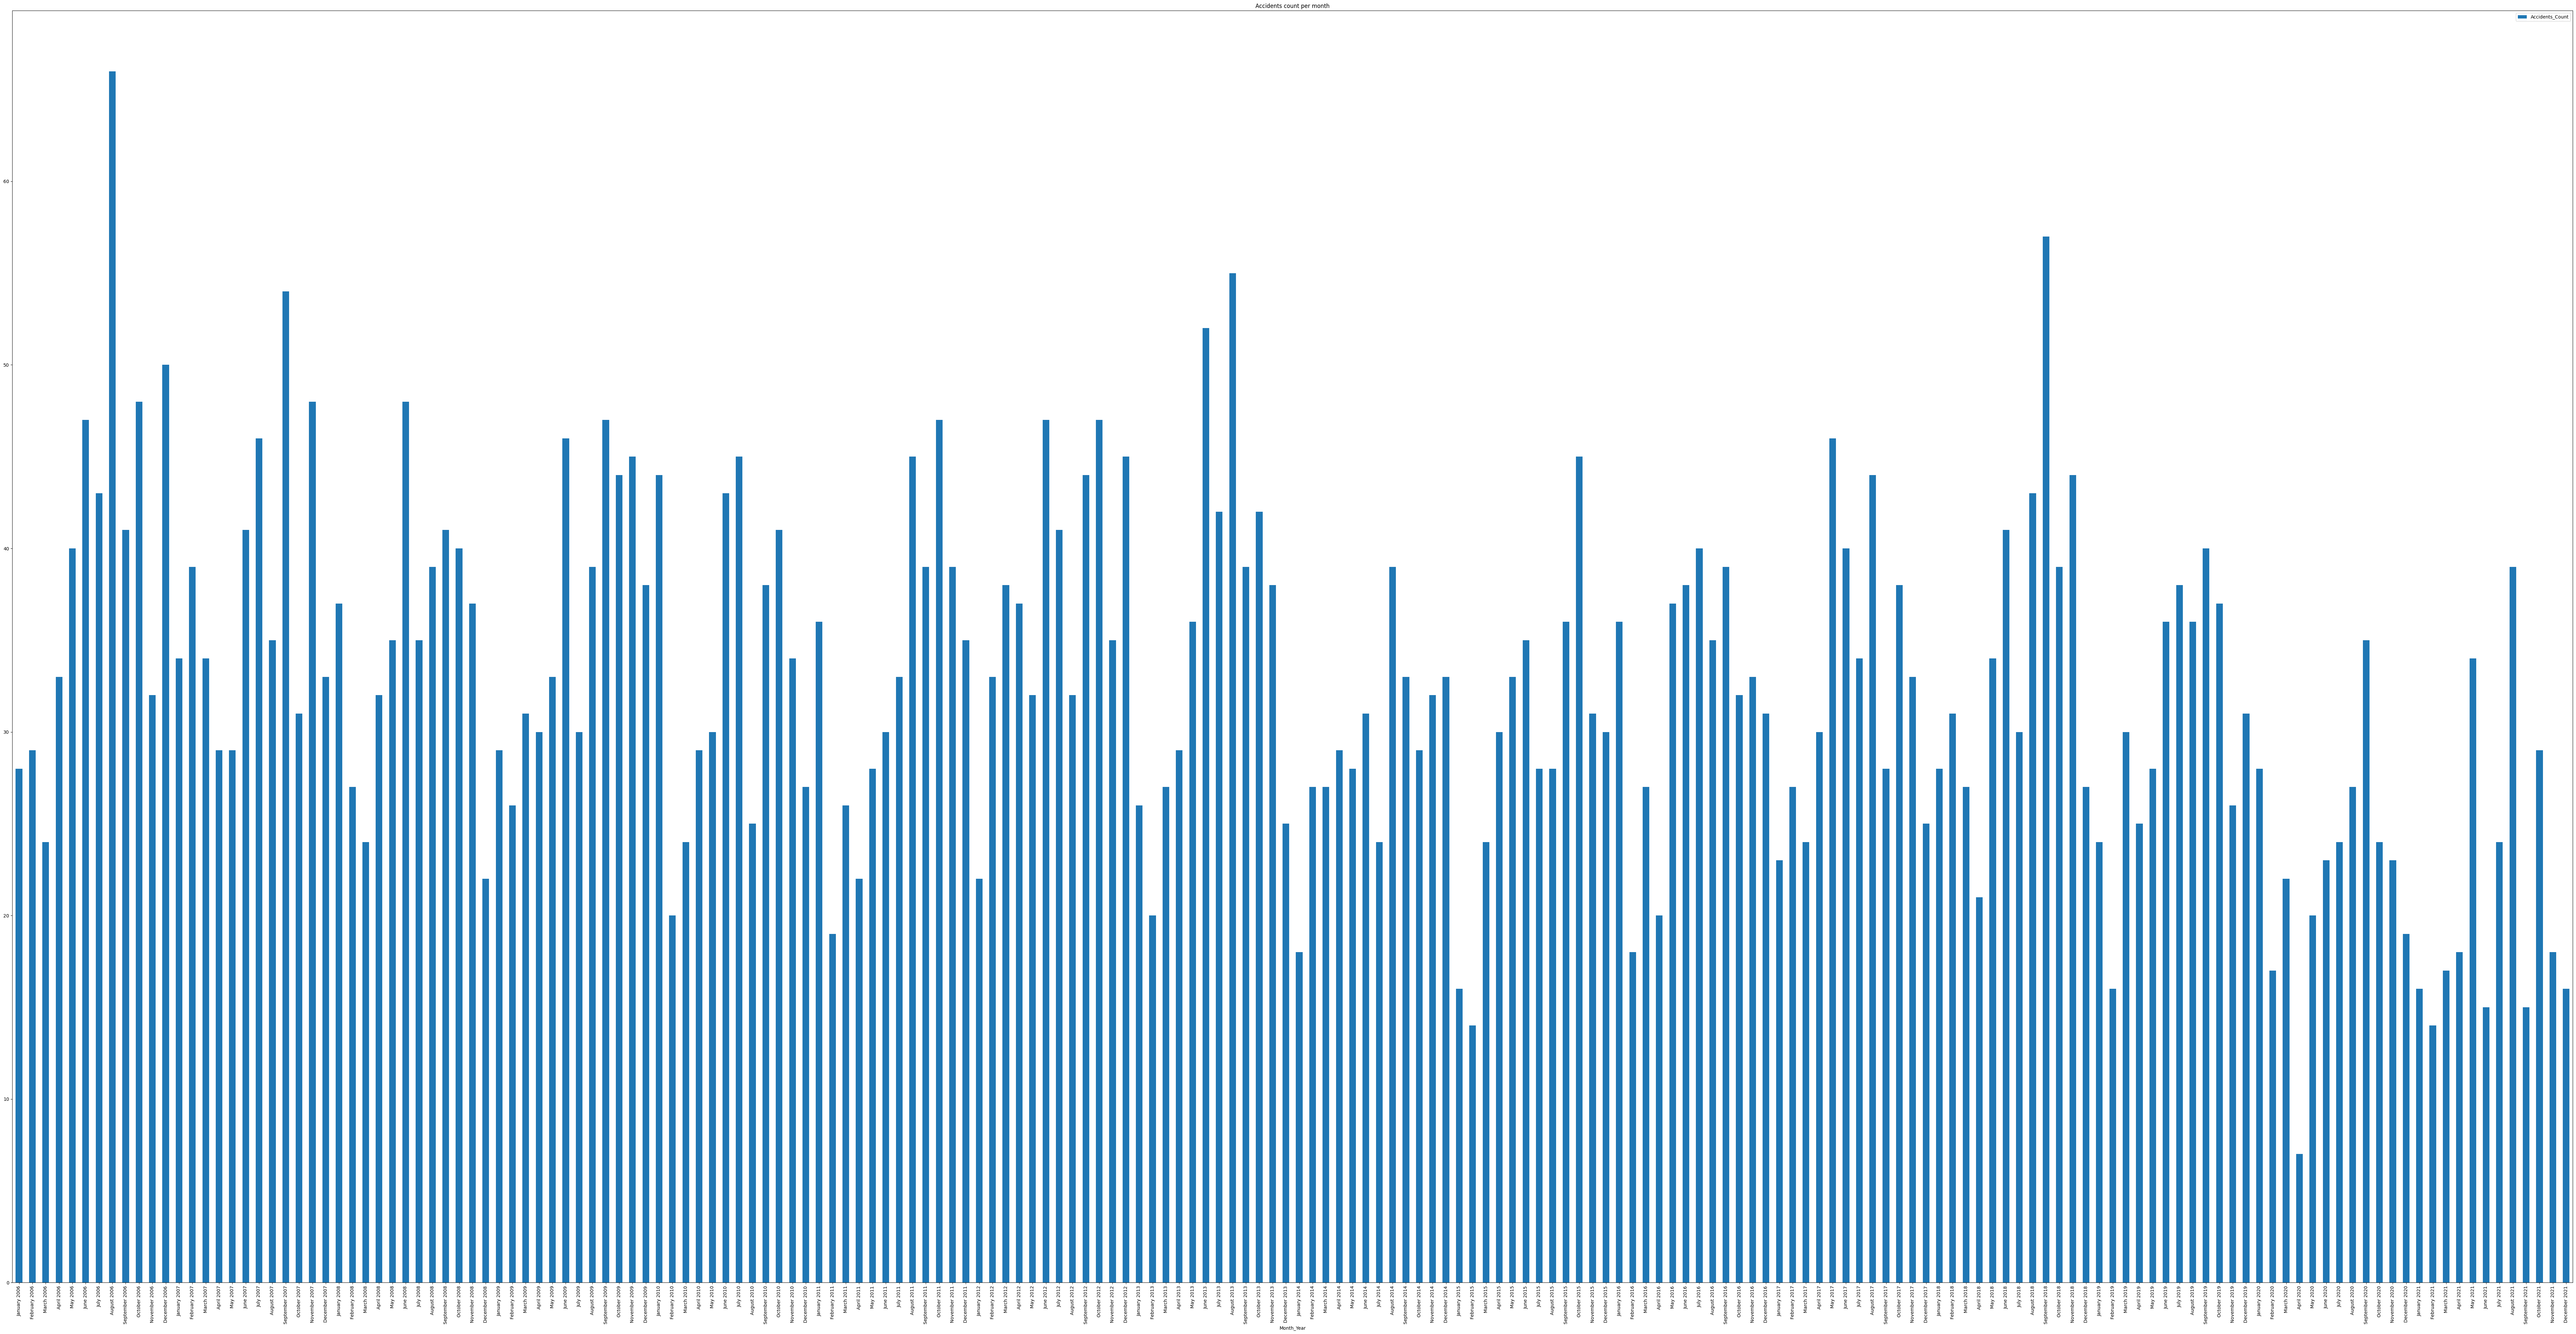

In [ ]:
#Create a copy of the DataFrame for this goal
mvc_month_year_df = mvc_ci_rlc_tvi_accidents_df.copy()
#Engineer new column Month_Year to group by
mvc_month_year_df['Month_Year'] = mvc_month_year_df.timestamp.dt.strftime(date_format='%B %Y')
#Drop all columns except Month_Year
column_names = mvc_month_year_df.columns.to_list()
column_names.remove('Month_Year')
mvc_month_year_df = mvc_month_year_df.drop(labels=column_names, axis=1)
#Create new column for Accidents_Count with initial value of 1
mvc_month_year_df['Accidents_Count'] = 1
#Group by Month_Year to get a count of accidents
mvc_month_year_df = mvc_month_year_df.groupby(by='Month_Year', as_index=False, dropna=False, sort=False).count()
#Plot Accidents_Count by Month_Year
mvc_month_year_df.plot(x='Month_Year', y='Accidents_Count', kind='bar', title="Accidents count per month", figsize=(100, 50))
plt.gcf().savefig("Accidents count per month.png")


In [ ]:
mvc_month_year_df

,Month_Year,Accidents_Count
0,January 2006,28
1,February 2006,29
2,March 2006,24
3,April 2006,33
4,May 2006,40
...,...,...
187,August 2021,39
188,September 2021,15
189,October 2021,29
190,November 2021,18


In [ ]:
mvc_month_year_df ['Year']=mvc_month_year_df['Month_Year'].str[-4:]

In [ ]:
mvc_month_year_df ['Month']=mvc_month_year_df['Month_Year'].str[:-5]

In [ ]:
my_dict = {"January":"01","February":"02","March":"03","April":"04",\
           "May":"05","June":"06","July":"07","August":"08",\
           "September":"09","October":"10","November":"11","December":"12"}
month_season = {"01": "Winter", "02": "Winter", "03": "Winter",
                 "04": "Spring", "05": "Spring", "06": "Spring",
                 "07": "Summer", "08": "Summer", "09": "Summer",
                 "10": "Autumn", "11": "Autumn", "12": "Autumn"}                      
mvc_month_year_df['Month_Num']= mvc_month_year_df['Month'].map(my_dict)
mvc_month_year_df['Season']= mvc_month_year_df['Month_Num'].map(month_season) 
mvc_month_year_df              
 ### now we have a summarized table of accidents versus month and year         

,Month_Year,Accidents_Count,Year,Month,Month_Num,Season
0,January 2006,28,2006,January,01,Winter
1,February 2006,29,2006,February,02,Winter
2,March 2006,24,2006,March,03,Winter
3,April 2006,33,2006,April,04,Spring
4,May 2006,40,2006,May,05,Spring
...,...,...,...,...,...,...
187,August 2021,39,2021,August,08,Summer
188,September 2021,15,2021,September,09,Summer
189,October 2021,29,2021,October,10,Autumn
190,November 2021,18,2021,November,11,Autumn


In [ ]:
mvc_month_year_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Month_Year       192 non-null    object
 1   Accidents_Count  192 non-null    int64 
 2   Year             192 non-null    object
 3   Month            192 non-null    object
 4   Month_Num        192 non-null    object
 5   Season           192 non-null    object
dtypes: int64(1), object(5)
memory usage: 9.1+ KB


In [ ]:
MetaSeasonalFrame_months = pd.pivot_table(mvc_month_year_df, values ='Accidents_Count', index =['Month_Num'],
                         columns =['Year'])
MetaSeasonalFrame_months

Year,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Month_Num,,,,,,,,,,,,,,,,
01,28,34,37,29,44,36,22,26,18,16,36,23,28,24,28,16
02,29,39,27,26,20,19,33,20,27,14,18,27,31,16,17,14
03,24,34,24,31,24,26,38,27,27,24,27,24,27,30,22,17
04,33,29,32,30,29,22,37,29,29,30,20,30,21,25,7,18
05,40,29,35,33,30,28,32,36,28,33,37,46,34,28,20,34
06,47,41,48,46,43,30,47,52,31,35,38,40,41,36,23,15
07,43,46,35,30,45,33,41,42,24,28,40,34,30,38,24,24
08,66,35,39,39,25,45,32,55,39,28,35,44,43,36,27,39
09,41,54,41,47,38,39,44,39,33,36,39,28,57,40,35,15


In [ ]:
MetaSeasonalFrame_seasons = pd.pivot_table(mvc_month_year_df, values ='Accidents_Count', index =['Season'],
                         columns =['Year'])
MetaSeasonalFrame_seasons

Year,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Season,,,,,,,,,,,,,,,,
Autumn,43.333333,37.333333,33.000000,42.333333,34.000000,40.333333,42.333333,35.000000,31.333333,35.333333,32.000000,32.000000,36.666667,31.333333,22.000000,21.000000
Spring,40.000000,33.000000,38.333333,36.333333,34.000000,26.666667,38.666667,39.000000,29.333333,32.666667,31.666667,38.666667,32.000000,29.666667,16.666667,22.333333
Summer,50.000000,45.000000,38.333333,38.666667,36.000000,39.000000,39.000000,45.333333,32.000000,30.666667,38.000000,35.333333,43.333333,38.000000,28.666667,26.000000
Winter,27.000000,35.666667,29.333333,28.666667,29.333333,27.000000,31.000000,24.333333,24.000000,18.000000,27.000000,24.666667,28.666667,23.333333,22.333333,15.666667


This graph shows the number of accidents recorded for each month of the year. We can see that there is trend in data showing a reduction in overall accident rates as time progresses and also seasonal increase in total amounts for Spring and Summer

# Analysis Goal #2a 

**Verify Seasonality**

Steps:
*   Identify which months to group per season e.g. Spring (Apr.-June), Summer (July-Sept.), Fall (Oct.-Dec.), and Winter (Jan.-Mar.)
*   List item





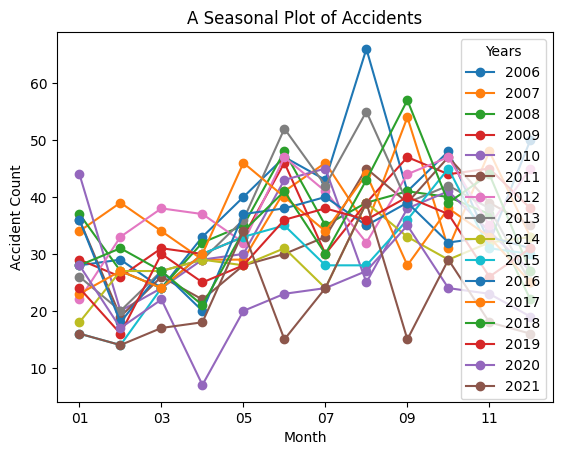

In [ ]:
MetaSeasonalFrame_months.columns.name = 'Years'
SeasonalPlot = MetaSeasonalFrame_months.plot(style="-o",
                                    title="A Seasonal Plot of Accidents")
SeasonalPlot.set_ylabel("Accident Count")
SeasonalPlot.set_xlabel("Month")
tmp = SeasonalPlot.plot()

# Analysis #2b


Generate a graph that shows the number of accidents in Toronto city per season (not by year)

Steps:

Identify which months to group per season e.g. Spring (Apr.-June), Summer (July-Sept.), Fall (Oct.-Dec.), and Winter (Jan.-Mar.)


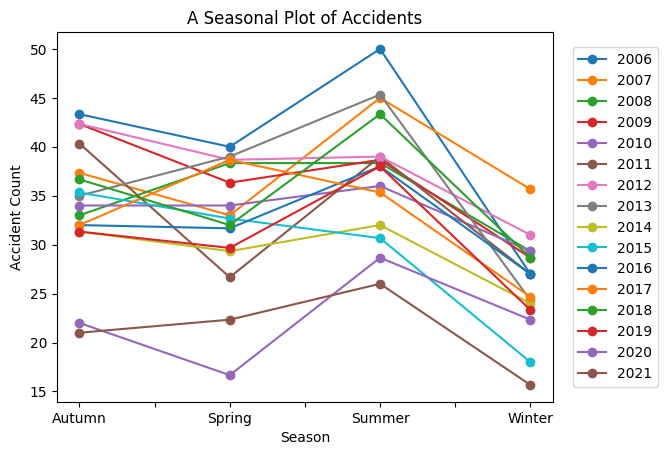

In [ ]:
MetaSeasonalFrame_seasons.columns.name = 'Years'
SeasonalPlot = MetaSeasonalFrame_seasons.plot(style="-o",
                                    title="A Seasonal Plot of Accidents")
SeasonalPlot.set_ylabel("Accident Count")
SeasonalPlot.set_xlabel("Season")
# Put a legend to the right of the current axis
SeasonalPlot.legend(bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0)
tmp = SeasonalPlot.plot()

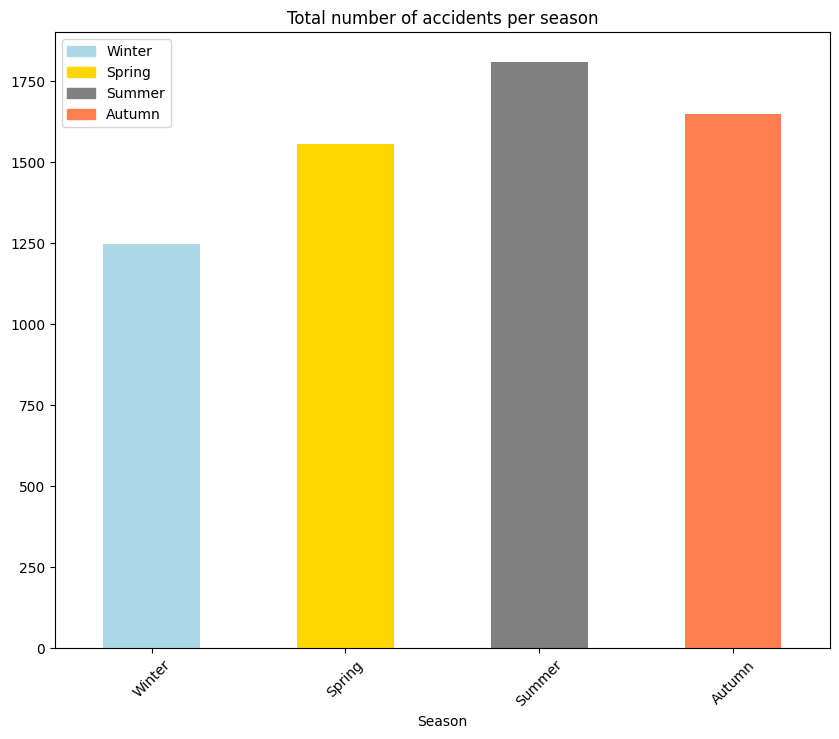

In [ ]:
#Create a copy of the DataFrame for this goal
mvc_season_df = mvc_ci_rlc_tvi_accidents_df.copy()
month_seasons = {"01": "Winter", "02": "Winter", "03": "Winter",
                 "04": "Spring", "05": "Spring", "06": "Spring",
                 "07": "Summer", "08": "Summer", "09": "Summer",
                 "10": "Autumn", "11": "Autumn", "12": "Autumn"}
#Create a new column for the Season
mvc_season_df["Season"] =  mvc_season_df.timestamp.dt.strftime(date_format='%m').apply(lambda month: month_seasons[month])
#Drop all columns except Season
column_names = mvc_season_df.columns.to_list()
column_names.remove('Season')
mvc_season_df = mvc_season_df.drop(labels=column_names, axis=1)
#Create new column for Accidents_Count with initial value of 1
mvc_season_df['Accidents_Count'] = 1
#Group by Season to get a count of accidents
mvc_season_df = mvc_season_df.groupby(by='Season', as_index=False, dropna=False, sort=False).count()
#Plot Accidents_Count by Season
colors={'Winter':'lightblue','Spring':'gold','Summer':'grey','Autumn':"coral"}
mvc_season_df.plot(x='Season', y='Accidents_Count',title="Total number of accidents per season", kind='bar', figsize=(10, 8), color=[colors[i] for i in mvc_season_df['Season']],rot=45)
handles = [mpatches.Patch(color=colors[i]) for i in colors]
labels = [f'{i}' for i in colors]
plt.legend(handles, labels)
plt.gcf().savefig("Total accidents count per season.png")

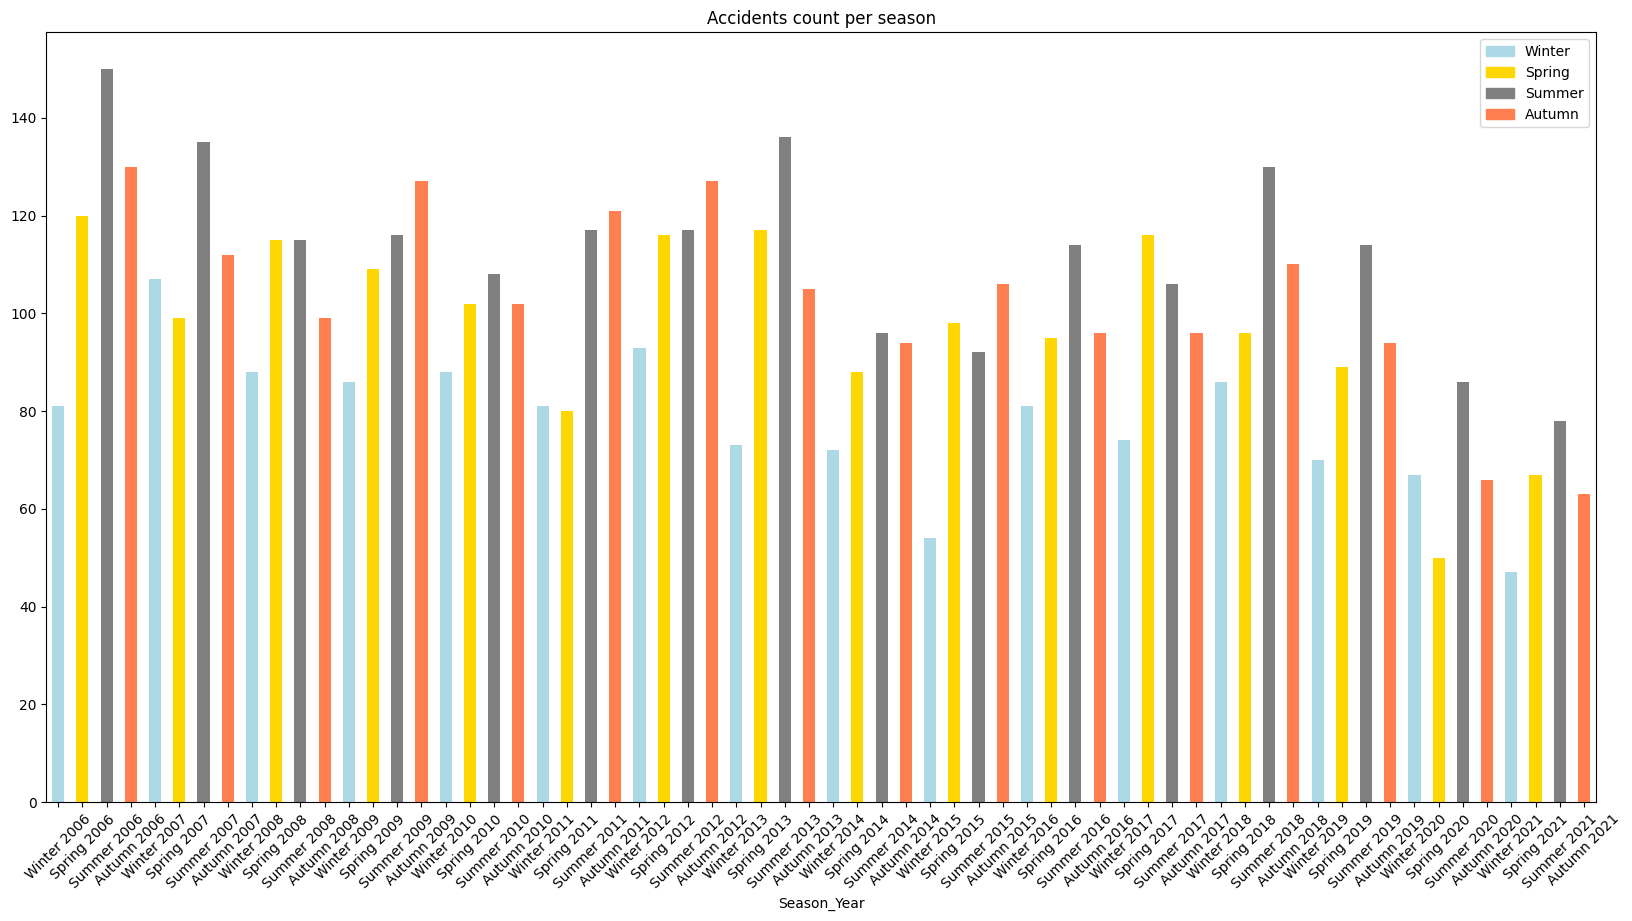

In [ ]:
#Create a copy of the DataFrame for this goal
mvc_season_year_df = mvc_ci_rlc_tvi_accidents_df.copy()
month_seasons = {"01": "Winter", "02": "Winter", "03": "Winter",
                 "04": "Spring", "05": "Spring", "06": "Spring",
                 "07": "Summer", "08": "Summer", "09": "Summer",
                 "10": "Autumn", "11": "Autumn", "12": "Autumn"}
#Create a new column for the Season_Year
mvc_season_year_df["Season_Year"] =  mvc_season_year_df.timestamp.dt.strftime(date_format='%m').apply(lambda month: month_seasons[month])
mvc_season_year_df["Season_Year"] = mvc_season_year_df.Season_Year + " " + mvc_season_year_df.timestamp.dt.strftime(date_format='%Y')
#Drop all columns except Season_Year
column_names = mvc_season_year_df.columns.to_list()
column_names.remove('Season_Year')
mvc_season_year_df = mvc_season_year_df.drop(labels=column_names, axis=1)
#Create new column for Accidents_Count with initial value of 1
mvc_season_year_df['Accidents_Count'] = 1
#Group by Season_Year to get a count of accidents
mvc_season_year_df = mvc_season_year_df.groupby(by='Season_Year', as_index=False, dropna=False, sort=False).count()
#Plot Accidents_Count by Month_Year
mvc_season_year_df['Season_only']=mvc_season_year_df['Season_Year'].str.split().str.get(0)
mvc_season_year_df
colors={'Winter':'lightblue','Spring':'gold','Summer':'grey','Autumn':"coral"}
mvc_season_year_df.plot(x='Season_Year', y='Accidents_Count', kind='bar', title="Accidents count per season",figsize=(20, 10), color=[colors[i] for i in mvc_season_year_df['Season_only']], rot=45)

handles = [mpatches.Patch(color=colors[i]) for i in colors]
labels = [f'{i}' for i in colors]
plt.legend(handles, labels)

plt.gcf().savefig("Accidents count per season.png")

From the above graph,we confirm that there is some seasonnality in number of accidents.

In [ ]:
mvc_season_year_df

,Season_Year,Accidents_Count,Season_only
0,Winter 2006,81,Winter
1,Spring 2006,120,Spring
2,Summer 2006,150,Summer
3,Autumn 2006,130,Autumn
4,Winter 2007,107,Winter
...,...,...,...
59,Autumn 2020,66,Autumn
60,Winter 2021,47,Winter
61,Spring 2021,67,Spring
62,Summer 2021,78,Summer


From the graph above we notice that the number of accidents are higher in the Summer.  

This might be due to the fact that there are more movements outside during this seasons, citizens spends more time outside, commute to different places, drive to further places and more often. Higher number of tourists in the city might also have an impact as there are more drivers, traffic and pedestrians in Summer.




---

# **Bigger picture**

From the above analysis, we notice that number of accidents and the number of victims vary on time depending on seasons.

Let's check is speed and alcohol have an impact

steps:


*   Copy data and clean it
*   transform speeding and alcohol to boolean variable.
*   Fill empty cell with 0 and replace Yes by 1 and No or Nan by 0
*   Group and aggregate on sum in order to calculate the number of accidents per month as well as the number of accidents where Alcohol was a factor and number of accident where speed was registered
*   Generate a 4 dimentional graph that has date (month and year) on the x axis, number of accidents on the y axis, the size of the bubbles is determined by the number of victims and the color is defined by the impact of alcohol or speed







---



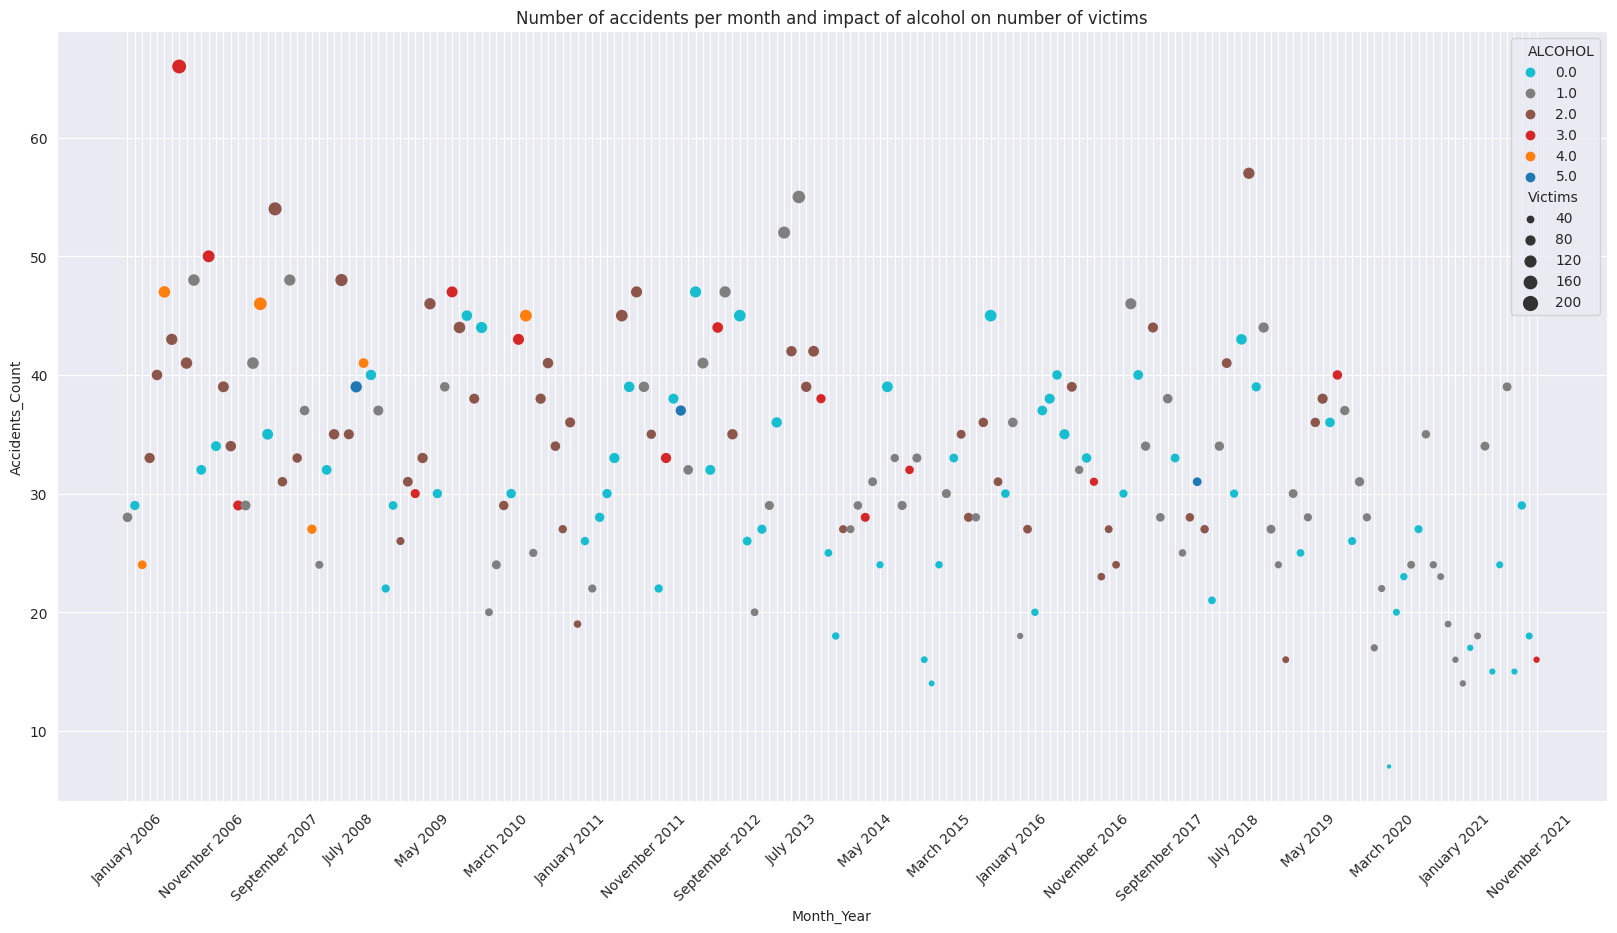

In [ ]:
#Create a copy of the DataFrame for this goal
mvc_month_year_df = mvc_ci_rlc_tvi_accidents_df.copy()
#Engineer new column Month_Year to group by
mvc_month_year_df['Month_Year'] = mvc_month_year_df.timestamp.dt.strftime(date_format='%B %Y')
#Drop all columns except Month_Year, Alcohol, speeding and victims
column_names = mvc_month_year_df.columns.to_list()
column_names.remove('Month_Year')
column_names.remove('ALCOHOL')
column_names.remove('SPEEDING')
column_names.remove('Victims')
mvc_month_year_df = mvc_month_year_df.drop(labels=column_names, axis=1)

#replace None values by NaN
mvc_month_year_df['SPEEDING'].replace('None', np.nan, inplace=True)
mvc_month_year_df['ALCOHOL'].replace('None', np.nan, inplace=True)
#replace yes values to 1
mvc_month_year_df['SPEEDING'].replace('Yes', 1, inplace=True)
mvc_month_year_df['ALCOHOL'].replace('Yes', 1, inplace=True)
#replace NaN values and empty cells by 0
mvc_month_year_df=mvc_month_year_df.fillna(0)
#Create new column for Accidents_Count with initial value of 1
mvc_month_year_df['Accidents_Count'] = 1
#Group by Month_Year to get a count of accidents
mvc_month_year_df = mvc_month_year_df.groupby('Month_Year', as_index=False, dropna=False, sort=False).sum()

#Generate the 4 dimentional graph where the dimensions are Date (month/year), number of accidents, alcohol, victims
with sns.axes_style("darkgrid"):
  fig, ax = plt.subplots(figsize=(20, 10))
  g = sns.scatterplot(
      data=mvc_month_year_df, 
      x="Month_Year", y="Accidents_Count",
      hue="ALCOHOL", size="Victims",
      sizes=(10, 100), linewidth=0, alpha=1, palette="tab10_r",
      ax=ax,
      )
  plt.xticks(rotation=45)
  for ind, label in enumerate(g.get_xticklabels()):
    if ind % 10 == 0:  # every 10th label is kept
        label.set_visible(True)
    else:
        label.set_visible(False)
  ax.set_title("Number of accidents per month and impact of alcohol on number of victims")

In [ ]:
mvc_month_year_df

,Month_Year,SPEEDING,ALCOHOL,Victims,Accidents_Count
0,January 2006,8.0,1.0,94,28
1,February 2006,7.0,0.0,89,29
2,March 2006,2.0,4.0,80,24
3,April 2006,8.0,2.0,109,33
4,May 2006,6.0,2.0,115,40
...,...,...,...,...,...
187,August 2021,9.0,1.0,81,39
188,September 2021,2.0,0.0,37,15
189,October 2021,7.0,0.0,71,29
190,November 2021,4.0,0.0,49,18


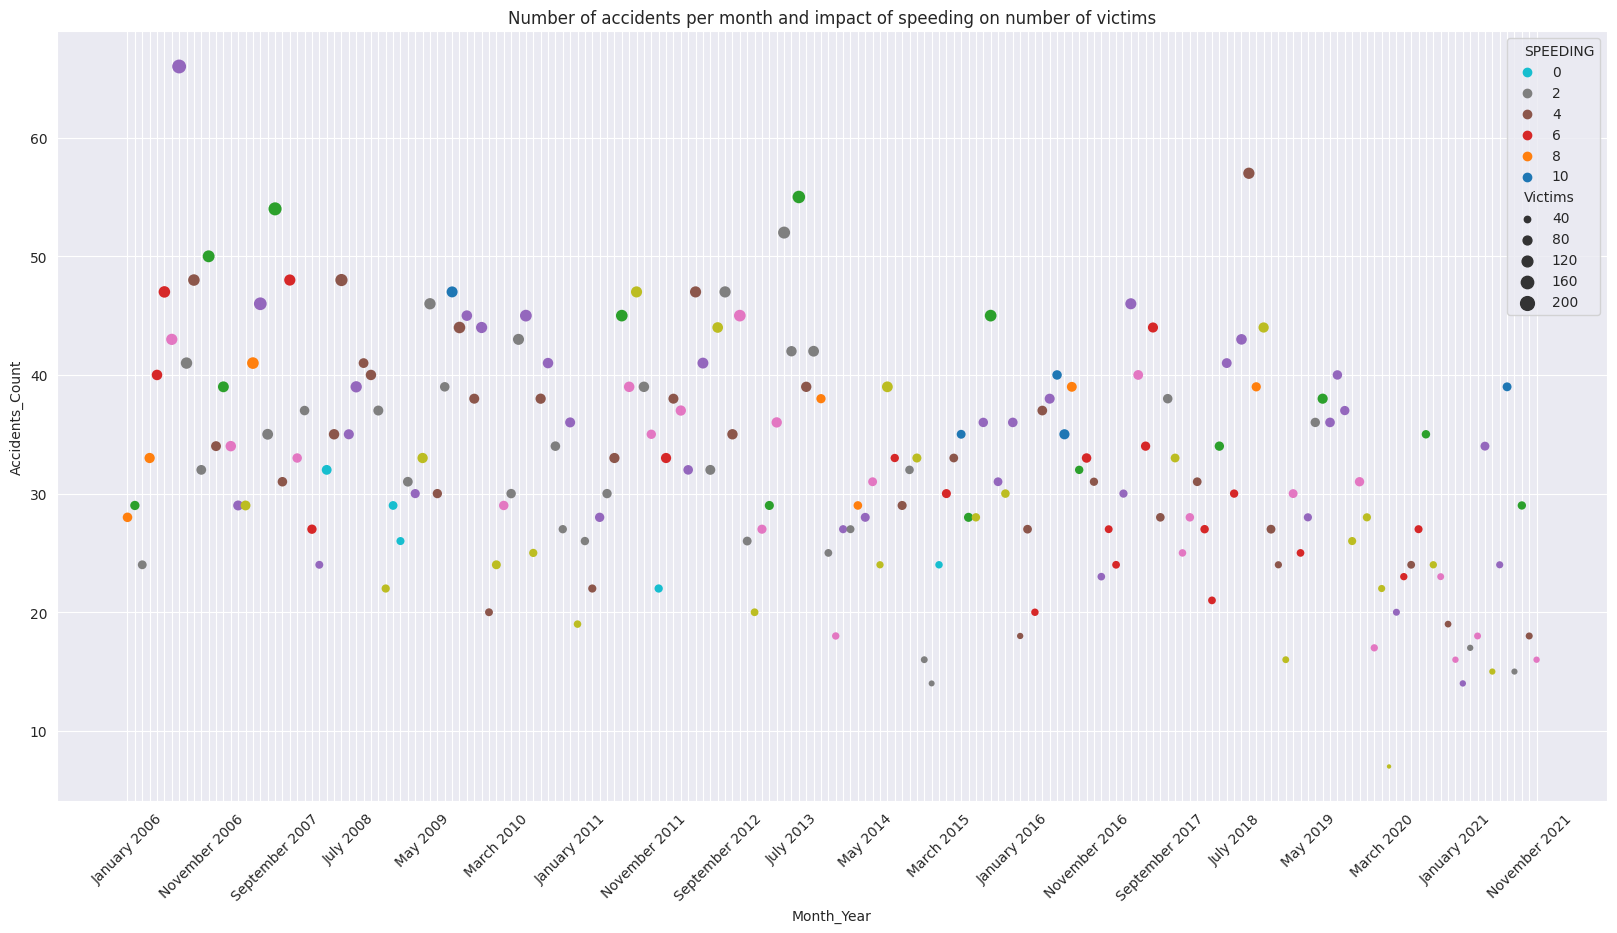

In [ ]:
#Generate the 4 dimentional graph where the dimensions are Date (month/year), number of accidents, speeding, victims
with sns.axes_style("darkgrid"):
  fig, ax = plt.subplots(figsize=(20, 10))
  g = sns.scatterplot(
      data=mvc_month_year_df, 
      x="Month_Year", y="Accidents_Count",
      hue="SPEEDING", size="Victims",
      sizes=(10, 100), linewidth=0, alpha=1, palette="tab10_r",
      ax=ax,
      )
  plt.xticks(rotation=45)
  for ind, label in enumerate(g.get_xticklabels()):
    if ind % 10 == 0:  # every 10th label is kept
        label.set_visible(True)
       
    else:
        label.set_visible(False)
        
  ax.set_title("Number of accidents per month and impact of speeding on number of victims")

In [ ]:
mvc_month_year_df.describe()     #Generate table of basic statistics metric of the above dataframe

,SPEEDING,ALCOHOL,Victims,Accidents_Count
count,192.000000,192.000000,192.000000,192.000000
mean,3.973958,1.244792,91.083333,32.619792
std,2.190974,1.161094,30.855402,9.493245
min,0.000000,0.000000,17.000000,7.000000
25%,2.000000,0.000000,69.000000,27.000000
50%,4.000000,1.000000,90.000000,32.000000
75%,5.000000,2.000000,110.000000,39.000000
max,10.000000,5.000000,203.000000,66.000000


If we look and the describtive statistics table, we can confirm that speed have a more important impact on the number of accidents than alcohol.

If we look at the max values, we notice that we registered up to 10 accidents per month related to speed. Alcohol might be involved as well but it is less frequent.

Also the mean value tells us that in a month, we register almost 4 accidents caused by speed while we register only 1 due to Alcohol.

# Analysis Goal #3

**Generate a graph that has multiple plot each one shows the number of accidents vs. a specific weather condition**

Steps:
1. Create a dataframe for weather related attributes
2. Isolate each individual attribute for Visibility, Light, and Road conditions and then count the number of accidents for each attribute (Note: Counter used since each individual row represents an unique accident based on the dataframe [mvc_ci_rlc_tvi_accidents_df] built for the project).
3. Create dataframes for each count and merge three dataframes to one weather dataframe
4. Graph result






In [ ]:
#Create a copy of the DataFrame for this goal
Conditions_df = mvc_ci_rlc_tvi_accidents_df.copy()
#Get the Counter function
from collections import Counter

In [ ]:
#Create a copy of the DataFrame for this goal
weather_df = mvc_ci_rlc_tvi_accidents_df.copy()
#Get the Counter function
from collections import Counter
Visibility = Counter(weather_df["VISIBILITY"])
Visibility_df = pd.DataFrame.from_dict(Visibility, orient='index').reset_index()
Visibility_df.rename(columns={'index':'WEATHER', 0:'ACC_NUMBERS'}, inplace=True)
Light = Counter(weather_df["LIGHT"])
Light_df = pd.DataFrame.from_dict(Light, orient='index').reset_index()
Light_df.rename(columns={'index':'WEATHER', 0:'ACC_NUMBERS'}, inplace=True)
RoadCond = Counter(weather_df["RDSFCOND"])
RoadCond_df = pd.DataFrame.from_dict(RoadCond, orient='index').reset_index()
RoadCond_df.rename(columns={'index':'WEATHER', 0:'ACC_NUMBERS'}, inplace=True)
weather_df=pd.concat([Visibility_df, RoadCond_df], axis=0, join='inner')
weather_df=pd.concat([weather_df, Light_df], axis=0, join='inner')

weather_df.head(28)
#1st Index set 0 to 8 is Visibility, 2nd Index 0 to 9 set is Road Conditions, 3rd Index 0 to 8 set is Light Conditions

,WEATHER,ACC_NUMBERS
0,Clear,5359
1,Snow,119
2,Other,40
3,Rain,694
4,Strong wind,4
5,"Fog, Mist, Smoke, Dust",16
6,Drifting Snow,7
7,Freezing Rain,15
8,None,9
0,Wet,1095


In [ ]:
#Create a copy of the DataFrame for this goal
weather_df = mvc_ci_rlc_tvi_accidents_df.copy()
#Get the Counter function
from collections import Counter
Visibility = Counter(weather_df["VISIBILITY"])
Visibility_df = pd.DataFrame.from_dict(Visibility, orient='index').reset_index()
Visibility_df.rename(columns={'index':'WEATHER', 0:'ACC_NUMBERS'}, inplace=True)
Light = Counter(weather_df["LIGHT"])
Light_df = pd.DataFrame.from_dict(Light, orient='index').reset_index()
Light_df.rename(columns={'index':'WEATHER', 0:'ACC_NUMBERS'}, inplace=True)
RoadCond = Counter(weather_df["RDSFCOND"])
RoadCond_df = pd.DataFrame.from_dict(RoadCond, orient='index').reset_index()
RoadCond_df.rename(columns={'index':'WEATHER', 0:'ACC_NUMBERS'}, inplace=True)
weather_df=pd.concat([Visibility_df, RoadCond_df], axis=0, join='inner')
weather_df=pd.concat([weather_df, Light_df], axis=0, join='inner')

#Organize data by conditions 

Conditions_weather = {"Clear": "Weather", "Snow": "Weather","Strong wind":"Weather",
                      "Fog, Mist, Smoke, Dust":"Weather","Drifting Snow":"Weather",
                      "Freezing Rain":"Weather","Wet":"Road Cond","Rain":"Weather",
                      "Slush":"Road Cond","Dry":"Road Cond","Ice":"Road Cond",
                      "Loose Snow":"Road Cond","Other":"unknown","Packed Snow":"Road Cond",
                      "Spilled liquid":"Road Cond","Loose Sand or Gravel":"Road Cond","None":"unknown","Dark":"Visibility",
                      "Dark, artificial":"Visibility","Daylight":"Visibility","Dusk":"Visibility","Dawn":"Visibility",
                      "Dusk, artificial":"Visibility","Dawn, artificial":"Visibility","Daylight, artificial":"Visibility"}

weather_df['Driving Conditions']= weather_df['WEATHER'].map(Conditions_weather)

weather_df.head(28)
#1st Index set 0 to 8 is Visibility, 2nd Index 0 to 9 set is Road Conditions, 3rd Index 0 to 8 set is Light Conditions

,WEATHER,ACC_NUMBERS,Driving Conditions
0,Clear,5359,Weather
1,Snow,119,Weather
2,Other,40,unknown
3,Rain,694,Weather
4,Strong wind,4,Weather
5,"Fog, Mist, Smoke, Dust",16,Weather
6,Drifting Snow,7,Weather
7,Freezing Rain,15,Weather
8,None,9,unknown
0,Wet,1095,Road Cond


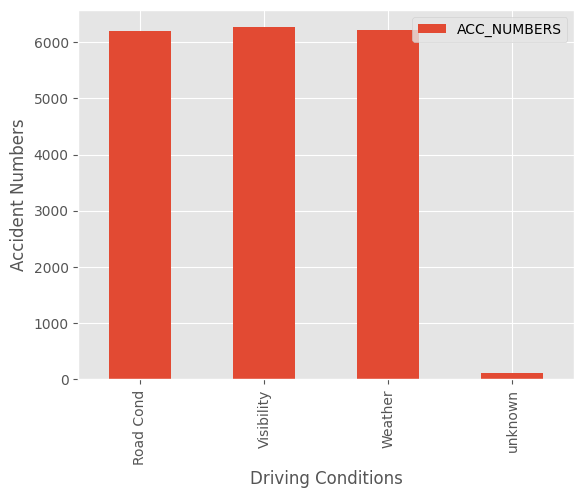

In [ ]:
x = weather_df.groupby(['Driving Conditions'])['ACC_NUMBERS'].sum()
Conditions_df = pd.DataFrame(x)
plt.style.use('ggplot')
Conditions_df.plot(kind='bar')
plt.xlabel("Driving Conditions")
plt.ylabel('Accident Numbers');
#weather_df.plot(x='Driving Conditions',y='ACC_NUMBERS')

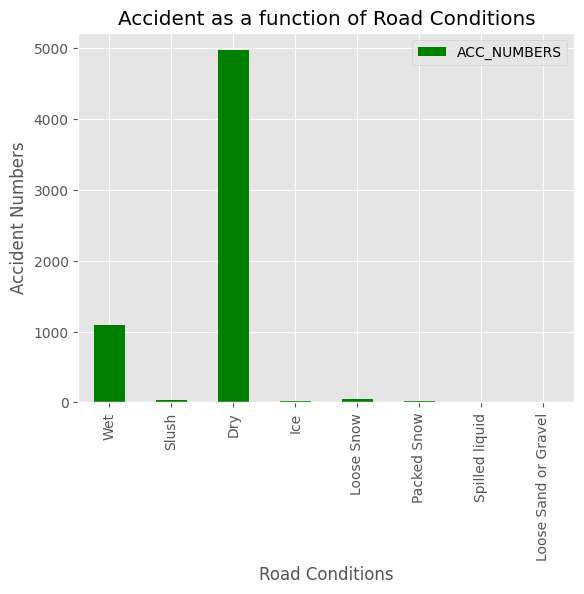

In [ ]:
### Breakdown of Each Driving Conditions Grouping: Road Conditions (Road Cond)
DR_Cond_Road_Cond_df = weather_df.loc[(weather_df['Driving Conditions'].str.contains('Road Cond'))]
                 
plt.style.use('ggplot')
DR_Cond_Road_Cond_df.plot('WEATHER','ACC_NUMBERS',kind='bar', color=['green'])
plt.title("Accident as a function of Road Conditions")
plt.xlabel("Road Conditions")
plt.ylabel('Accident Numbers');
plt.gcf().savefig("Accident as a function of Road Conditions.png")
# This is for time range of 2006 to 2021 ###

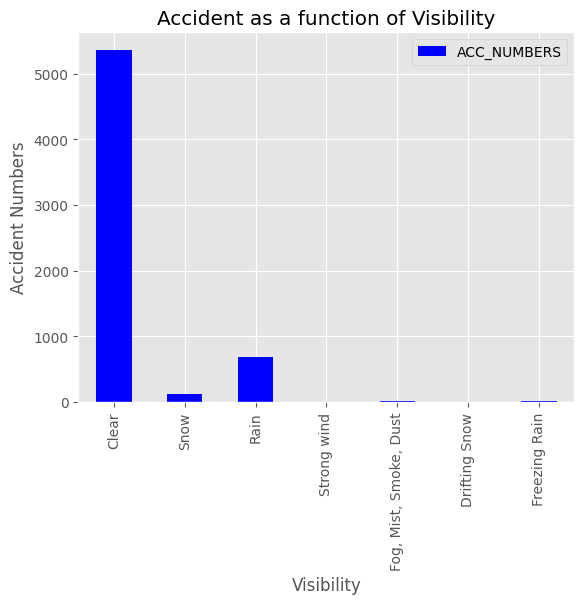

In [ ]:
### Breakdown of Each Driving Conditions Grouping: Weather
DR_Cond_Road_Cond_df = weather_df.loc[(weather_df['Driving Conditions'].str.contains('Weather'))]
                 
plt.style.use('ggplot')
DR_Cond_Road_Cond_df.plot('WEATHER','ACC_NUMBERS',kind='bar', color=['blue'])
plt.title("Accident as a function of Visibility")
plt.xlabel("Visibility")
plt.ylabel('Accident Numbers');
plt.gcf().savefig("Accident as a function of Visibility.png")

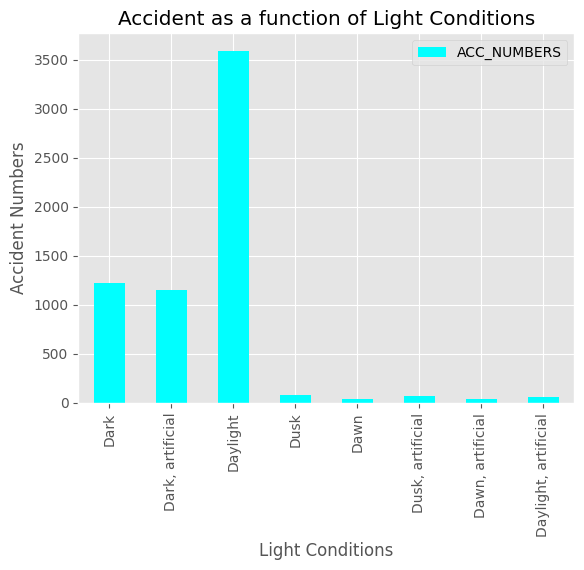

In [ ]:
### Breakdown of Each Driving Conditions Grouping: Visibility
DR_Cond_Road_Cond_df = weather_df.loc[(weather_df['Driving Conditions'].str.contains('Visibility'))]
                 
plt.style.use('ggplot')
DR_Cond_Road_Cond_df.plot('WEATHER','ACC_NUMBERS',kind='bar', color=['cyan'])
plt.title("Accident as a function of Light Conditions")
plt.xlabel("Light Conditions")
plt.ylabel('Accident Numbers');
plt.gcf().savefig("Accident as a function of Light Conditions.png")

Looking at each Weather item it appears the majority of accidents occured when the: 1) visibility was clear, 2) road conditions were dry, and 3) it was daylight.



---


# Analysis Goal #4

**Compare number of accidents at intersection with high volume with number of accidents in total >>> calculate rate, correlation**

steps:


*   Create DF that contain intersection description and accident count
*   Group elements by intersection description
*   Add data on intersection volume for each intersection (using a loop that go through of the new DF and assign values from the original DF)
*   Generate scatter plot that shows the number of accidents against the intersection volume
*   Generate scatter plot that shows the number of accidents against the pedestrian count
*   Calculate the correlation to confirm relationship between variables


---










In [ ]:
#copy columns needed from original DF
high_volume_df=pd.DataFrame(data={'accident_number':mvc_ci_rlc_tvi_df['ACCNUM'],'victims':mvc_ci_rlc_tvi_df['Victims'], 'Intersection_Description':mvc_ci_rlc_tvi_df['INTERSECTION_DESC'],
                                  'hourly_cars':mvc_ci_rlc_tvi_df['hourly_cars'],'hourly_trucks':mvc_ci_rlc_tvi_df['hourly_trucks'],'hourly_buses':mvc_ci_rlc_tvi_df['hourly_buses'],
                                  'hourly_bicycles':mvc_ci_rlc_tvi_df['hourly_bicycles'], 'hourly_pedestrians':mvc_ci_rlc_tvi_df['hourly_pedestrians'] })#.set_index('Intersection_Description')

high_volume_df=high_volume_df.dropna() #drop cells with NA or empty
high_volume_df=high_volume_df.loc[(high_volume_df!=0).any(axis=1)]   #drop cells with all zeros

#group by accident number and constant columns in order to calculate number of victims per accident
high_volume_grouped_df = high_volume_df.groupby(['accident_number','Intersection_Description','hourly_cars', 'hourly_trucks', 'hourly_buses', 'hourly_bicycles', 'hourly_pedestrians'])
high_volume__victims_df=high_volume_grouped_df.aggregate('sum')
high_volume__victims_df=high_volume__victims_df.reset_index()

#calculating number of accidents per intersection
high_volume__victims_df['accident_count']=1
high_volume__victims_df=high_volume__victims_df.drop(['accident_number'], axis=1)

high_volume__victims_df['vehicles_volume']=high_volume__victims_df['hourly_cars']+high_volume__victims_df['hourly_trucks']+high_volume__victims_df['hourly_buses']+high_volume__victims_df['hourly_bicycles']
high_volume_inter_df_grouped = high_volume__victims_df.groupby(['Intersection_Description','hourly_cars','hourly_trucks','hourly_buses','hourly_bicycles','hourly_pedestrians','vehicles_volume'])

df_aggregated=high_volume_inter_df_grouped.aggregate('sum') #calculate total values per intersection
df_aggregated=df_aggregated.reset_index()

df_aggregated #in this resulting DF column victims shows total number of victims in each intersection


,Intersection_Description,hourly_cars,hourly_trucks,hourly_buses,hourly_bicycles,hourly_pedestrians,vehicles_volume,victims,accident_count
0,ADELAIDE ST E / BERKELEY ST,1060.225000,56.200000,3.125000,11.975000,103.325000,1131.525000,7,2
1,ADELAIDE ST E / CHURCH ST,1661.500000,77.281250,15.468750,92.562500,902.750000,1846.812500,5,2
2,ADELAIDE ST E / FREDERICK ST,1065.875000,50.333333,7.666667,26.500000,499.666667,1150.375000,2,1
3,ADELAIDE ST E / GEORGE ST,1153.333333,69.291667,5.416667,40.416667,496.000000,1268.458333,2,1
4,ADELAIDE ST E / PARLIAMENT ST,1347.611111,77.305556,20.152778,30.777778,122.194444,1475.847222,4,1
...,...,...,...,...,...,...,...,...,...
1434,YORK ST / HARBOUR ST,1846.666667,74.000000,28.458333,0.000000,295.000000,1949.125000,6,2
1435,YORK ST / LAKE SHORE BLVD W,2304.437500,93.625000,34.604167,7.666667,536.625000,2440.333333,2,1
1436,YORK ST / QUEENS QUAY W,912.416667,51.458333,52.333333,0.000000,518.791667,1016.208333,13,6
1437,YORK ST / WELLINGTON ST W,1018.025000,57.350000,13.900000,32.950000,2370.125000,1122.225000,9,4


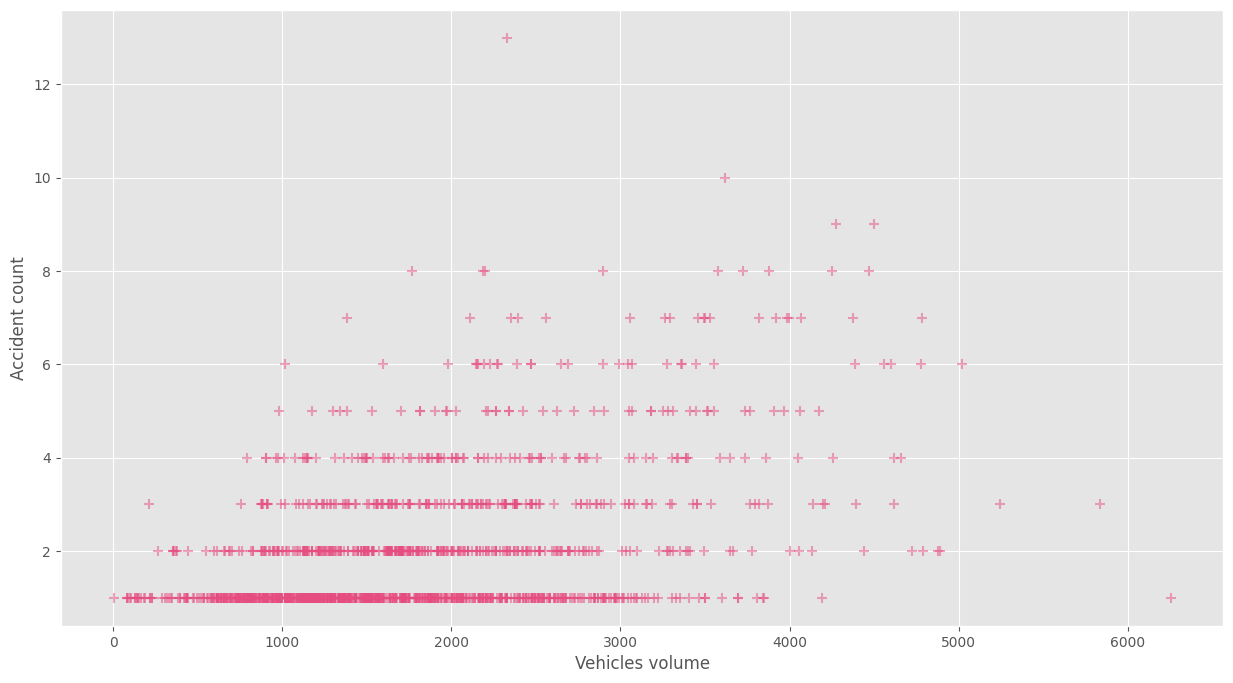

In [ ]:
#plotting the scatter chart showing the number of accidents against vehicule volume
plt.figure(figsize=(15,8))
plt.scatter(
    x=df_aggregated['vehicles_volume'], y=df_aggregated["accident_count"], 
    s=50, 
    color=(0.9,0.3,0.5), 
    alpha=0.5, 
    marker="+",
    )
plt.xlabel("Vehicles volume"); plt.ylabel("Accident count");

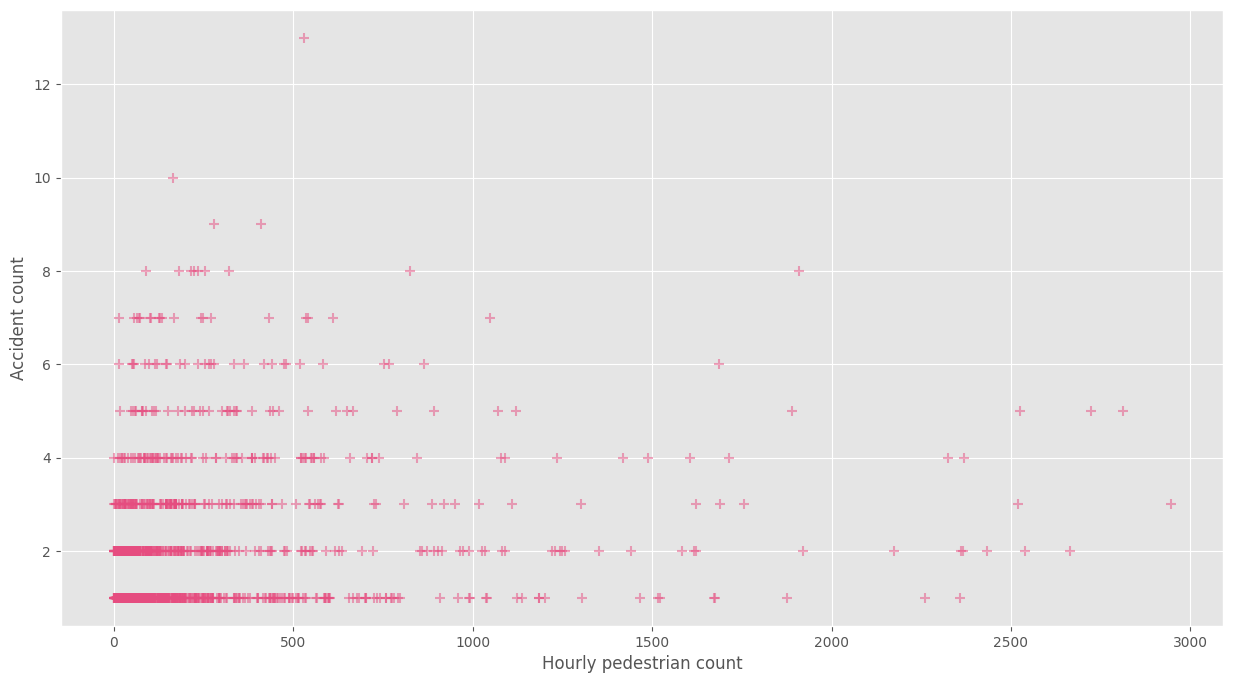

In [ ]:
#plotting the scatter chart showing the number of accidents against pedestrian volume
plt.figure(figsize=(15,8))
plt.scatter(
    x=df_aggregated["hourly_pedestrians"], y=df_aggregated["accident_count"], 
    s=50, 
    color=(0.9,0.3,0.5), 
    alpha=0.5, 
    marker="+",
    )
plt.xlabel("Hourly pedestrian count"); plt.ylabel("Accident count");

In [ ]:
#calculating correlation coefficiant 
df_aggregated["vehicles_volume"].corr(df_aggregated["accident_count"])

0.4456214514906035

In [ ]:
df_aggregated["hourly_pedestrians"].corr(df_aggregated["accident_count"])

0.21988594221782118



---

From the calculation we can say that the number of vehicles have some sort of impact on the number of accidents. But there isn't a strong correlation between the two variables


---



# Analysis Goal #5

**Generate a graph that shows the number of accidents at intersections with Red Light Cameras** 

Steps:


*   Explore data to see how may accidents at intersections with and without RLC
*   Create dataframe that has year and intersections
*   Count the number of accidents at intersections with RLC and without RLC
*   Plot a graph that shows number of accidents at intersection with RLC and without RLC






In [ ]:
#Create a copy of the DataFrame for this goal
RLC_acc_df = mvc_ci_rlc_tvi_accidents_df.copy()
#Count the number of accidents that had a RLC activated (True vs. False)
print(RLC_acc_df['RLC_Activated'].value_counts()) 
#Create a new dataframe filtered for intersections
RLC_acc_int_df = RLC_acc_df[RLC_acc_df['INTERSECTION_DESC'].notna()]
#Count the number of accidents at intersections that had a RLC activated (True vs. False)
print(RLC_acc_int_df['RLC_Activated'].value_counts()) 


False    6075
True      188
Name: RLC_Activated, dtype: int64
False    3545
True      188
Name: RLC_Activated, dtype: int64


In [ ]:
#Create a new dataframe with only needed columns
RLC_acc_int_df2=pd.DataFrame(data={'YEAR':RLC_acc_int_df['YEAR'],'RLC_Activated':RLC_acc_int_df['RLC_Activated']}).set_index('YEAR')
RLC_acc_int_df3 = RLC_acc_int_df2.loc[RLC_acc_int_df2['RLC_Activated']==True]
RLC_acc_int_df4 = RLC_acc_int_df3.groupby(['YEAR']).count()
RLC_acc_int_df4.rename(columns={'RLC_Activated':'RLC Yes'},inplace=True)
RLC_acc_int_df5 = RLC_acc_int_df2.loc[RLC_acc_int_df2['RLC_Activated']==False]
RLC_acc_int_df6 = RLC_acc_int_df5.groupby(['YEAR']).count()
RLC_acc_int_df6.rename(columns={'RLC_Activated':'RLC No'},inplace=True)
RLC_acc_int_df7 = pd.concat([RLC_acc_int_df6, RLC_acc_int_df4], axis=1)
RLC_acc_int_df7['RLC Yes'] = RLC_acc_int_df7['RLC Yes'].fillna(0)
RLC_acc_int_df7['Total Accidents'] = RLC_acc_int_df7['RLC No'] + RLC_acc_int_df7['RLC Yes']
RLC_acc_int_df7 = RLC_acc_int_df7[['Total Accidents', 'RLC No', 'RLC Yes']]
RLC_acc_int_df7.head(10)

,Total Accidents,RLC No,RLC Yes
YEAR,,,
2006,316.0,316,0.0
2007,273.0,273,0.0
2008,243.0,242,1.0
2009,239.0,229,10.0
2010,245.0,228,17.0
2011,204.0,198,6.0
2012,308.0,293,15.0
2013,284.0,269,15.0
2014,212.0,202,10.0


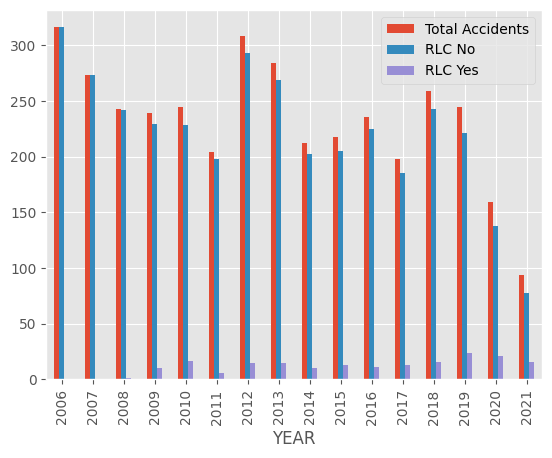

<Figure size 640x480 with 0 Axes>

In [ ]:
RLC_acc_int_df7.plot.bar()
plt.show()
plt.gcf().savefig("Total accidents and presence of Red-light Cameras.png")

There appears to be a trend of less accidents over time for the periods of 2006 - 2011. The total accidents increased in 2012 and then continued to decline until 2017. A sharp drop in accidents occurred in 2020 and 2021 and this may be influenced by the COVID-19 pandemic where individuals were less likely to leave their homes.

From a global perspective, we don't see a big impact of the adoption of RLC on the total number of accidents in the city of Toronto.

let's have a closer look and analyze the number of accidents per intersection


In [ ]:
RLC_acc_int_stat_df7 = RLC_acc_int_df7.copy()
RLC_acc_int_stat_df7.describe()

,Total Accidents,RLC No,RLC Yes
count,16.000000,16.000000,16.000000
mean,233.312500,221.562500,11.750000
std,54.985718,57.761543,7.094599
min,94.000000,78.000000,0.000000
25%,210.000000,201.000000,9.000000
50%,241.000000,226.500000,13.000000
75%,262.500000,249.500000,16.000000
max,316.000000,316.000000,24.000000


In [ ]:
#Create a copy of the DataFrame
mvc_intersections_acc_df = mvc_ci_rlc_tvi_accidents_df.copy()
#Get the Counter function
from collections import Counter
#Count the locations of the Accidents to identify number and type of traffic controls
Acc_Traffic_Control = Counter(mvc_intersections_acc_df["TRAFFCTL"])
Acc_Traffic_Control

# Analysis Goal #6

**Compare the number of accidents before RLC with number of accidents after RLC at intersections**

Steps:


*   Create DF with needed columns
*   Calculate number of victims for each accident
*   Count number of accidents for each intersections
*   Split Dataframe in 2 according to activation status (False or True)
*   Drop unneeded columns and calculate nb of accidents before activation for False DF and after for True DF
*   Merge the 2 Dataframes on "inner" basis to keep only intersection that have data before and after RLC
*   Plot different bar charts to visualize the variation in number of accidents










In [ ]:
#making a copy of the original DataFrame
copy_df=mvc_ci_rlc_tvi_df.copy()
copy_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17488 entries, 0 to 17487
Data columns (total 66 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ACCNUM                17488 non-null  int64         
 1   YEAR                  17488 non-null  int64         
 2   DATE                  17488 non-null  object        
 3   TIME                  17488 non-null  int64         
 4   STREET1               17488 non-null  object        
 5   STREET2               17488 non-null  object        
 6   OFFSET                17488 non-null  object        
 7   ROAD_CLASS            17488 non-null  object        
 8   DISTRICT              17488 non-null  object        
 9   WARDNUM               16963 non-null  float64       
 10  LOCCOORD              17488 non-null  object        
 11  ACCLOC                17488 non-null  object        
 12  TRAFFCTL              17488 non-null  object        
 13  VISIBILITY      

In [ ]:
#From the main DataFrame keeping only needed columns
RLC_int_df=pd.DataFrame(data={'Accident_nb':copy_df['ACCNUM'],'Acc_date':copy_df['DATE'],'intersection_desc':copy_df['INTERSECTION_DESC'], 'RLC_activated':copy_df['RLC_Activated'],'victims':copy_df['Victims']})
RLC_int_df

,Accident_nb,Acc_date,intersection_desc,RLC_activated,victims
0,893184,2006-01-01,NaN,False,1
1,893184,2006-01-01,NaN,False,1
2,913296,2006-06-25,NaN,False,1
3,893184,2006-01-01,NaN,False,1
4,893184,2006-01-01,NaN,False,1
...,...,...,...,...,...
17483,1001982074,2021-10-15,BURNHAMTHORPE RD / SHAVER AVE N,False,1
17484,1001982074,2021-10-15,BURNHAMTHORPE RD / SHAVER AVE N,False,1
17485,1001983260,2021-10-15,RICHMOND ST W / DUNCAN ST,False,1
17486,1001983260,2021-10-15,RICHMOND ST W / DUNCAN ST,False,1


In [ ]:
RLC_int_df=RLC_int_df.dropna()   #dropping empty cells
RLC_int_df

,Accident_nb,Acc_date,intersection_desc,RLC_activated,victims
5,911336,2006-06-28,BIRCHMOUNT RD / MODERN RD,False,1
7,911336,2006-06-28,BIRCHMOUNT RD / MODERN RD,False,1
9,911336,2006-06-28,BIRCHMOUNT RD / MODERN RD,False,1
11,915319,2006-06-28,KING ST W / YORK ST,False,1
14,918360,2006-07-18,YONGE ST / LORD SEATON RD,False,1
...,...,...,...,...,...
17483,1001982074,2021-10-15,BURNHAMTHORPE RD / SHAVER AVE N,False,1
17484,1001982074,2021-10-15,BURNHAMTHORPE RD / SHAVER AVE N,False,1
17485,1001983260,2021-10-15,RICHMOND ST W / DUNCAN ST,False,1
17486,1001983260,2021-10-15,RICHMOND ST W / DUNCAN ST,False,1


In [ ]:
#Calculating the number of victims per accident
RLC_int_acc_df=RLC_int_df.groupby(['Accident_nb', 'Acc_date', 'intersection_desc','RLC_activated'])
RLC_int_acc_df=RLC_int_acc_df.aggregate('sum')
RLC_int_acc_df

,,,,victims
Accident_nb,Acc_date,intersection_desc,RLC_activated,
25301,2020-01-04,EGLINTON AVE E / BAYVIEW AVE,False,2
37330,2020-01-06,SHERIDAN AVE / DUNDAS ST W,False,2
45664,2020-01-07,EGLINTON AVE E / PHARMACY AVE,False,3
56815,2020-01-09,MARTIN GROVE RD / BELFIELD RD,False,4
66893,2020-01-10,CRUIKSHANK AVE / CARLAW AVE,False,2
...,...,...,...,...
9002471073,2019-12-23,LAMBETH RD / ROYAL YORK RD,False,3
9002481518,2019-12-25,DON MILLS RD / SHEPPARD AVE E,True,2
9002500260,2019-12-28,BAY ST / GERRARD ST W,False,3


In [ ]:
#reseting the index
RLC_int_acc_df=RLC_int_acc_df.reset_index()
RLC_int_acc_df

,Accident_nb,Acc_date,intersection_desc,RLC_activated,victims
0,25301,2020-01-04,EGLINTON AVE E / BAYVIEW AVE,False,2
1,37330,2020-01-06,SHERIDAN AVE / DUNDAS ST W,False,2
2,45664,2020-01-07,EGLINTON AVE E / PHARMACY AVE,False,3
3,56815,2020-01-09,MARTIN GROVE RD / BELFIELD RD,False,4
4,66893,2020-01-10,CRUIKSHANK AVE / CARLAW AVE,False,2
...,...,...,...,...,...
3728,9002471073,2019-12-23,LAMBETH RD / ROYAL YORK RD,False,3
3729,9002481518,2019-12-25,DON MILLS RD / SHEPPARD AVE E,True,2
3730,9002500260,2019-12-28,BAY ST / GERRARD ST W,False,3
3731,9002501134,2019-12-28,MARTIN GROVE RD / DIXON RD,False,3


In [ ]:
RLC_int_acc_df['Accident_count']=1   #creating new column so we can count the number of accidents
RLC_int_acc_df

,Accident_nb,Acc_date,intersection_desc,RLC_activated,victims,Accident_count
0,25301,2020-01-04,EGLINTON AVE E / BAYVIEW AVE,False,2,1
1,37330,2020-01-06,SHERIDAN AVE / DUNDAS ST W,False,2,1
2,45664,2020-01-07,EGLINTON AVE E / PHARMACY AVE,False,3,1
3,56815,2020-01-09,MARTIN GROVE RD / BELFIELD RD,False,4,1
4,66893,2020-01-10,CRUIKSHANK AVE / CARLAW AVE,False,2,1
...,...,...,...,...,...,...
3728,9002471073,2019-12-23,LAMBETH RD / ROYAL YORK RD,False,3,1
3729,9002481518,2019-12-25,DON MILLS RD / SHEPPARD AVE E,True,2,1
3730,9002500260,2019-12-28,BAY ST / GERRARD ST W,False,3,1
3731,9002501134,2019-12-28,MARTIN GROVE RD / DIXON RD,False,3,1


In [ ]:
RLC_int_acc_df=RLC_int_acc_df.drop(['Accident_nb'],axis=1)    #dopping accident number as we won't need it
RLC_int_acc_df


,index,Acc_date,intersection_desc,RLC_activated,victims,Accident_count
0,0,2020-01-04,EGLINTON AVE E / BAYVIEW AVE,False,2,1
1,1,2020-01-06,SHERIDAN AVE / DUNDAS ST W,False,2,1
2,2,2020-01-07,EGLINTON AVE E / PHARMACY AVE,False,3,1
3,3,2020-01-09,MARTIN GROVE RD / BELFIELD RD,False,4,1
4,4,2020-01-10,CRUIKSHANK AVE / CARLAW AVE,False,2,1
...,...,...,...,...,...,...
3728,3728,2019-12-23,LAMBETH RD / ROYAL YORK RD,False,3,1
3729,3729,2019-12-25,DON MILLS RD / SHEPPARD AVE E,True,2,1
3730,3730,2019-12-28,BAY ST / GERRARD ST W,False,3,1
3731,3731,2019-12-28,MARTIN GROVE RD / DIXON RD,False,3,1


In [ ]:
#splitting the dataframe in 2, one for data before activation of RLC, the second one is for data after activation of RLC
RLC_int_acc_false_df=RLC_int_acc_df.loc[RLC_int_acc_df['RLC_activated']==False]
RLC_int_acc_true_df=RLC_int_acc_df.loc[RLC_int_acc_df['RLC_activated']==True]

In [ ]:
RLC_int_acc_false_df2=RLC_int_acc_false_df.rename(columns={'victims':'victims_false', 'Accident_count':'accident_false'})
RLC_int_acc_false_df2

,index,Acc_date,intersection_desc,RLC_activated,victims_false,accident_false
172,172,2006-01-01,DANFORTH AVE / WEST LYNN AVE,False,5,1
61,61,2006-01-02,BATHURST ST / DUNDAS ST W,False,2,1
57,57,2006-01-06,DON MILLS RD / LEITH HILL RD,False,2,1
58,58,2006-01-08,ISLINGTON AVE / GOLFDOWN DR,False,6,1
73,73,2006-01-08,FRONT ST E / PARLIAMENT ST,False,4,1
...,...,...,...,...,...,...
2359,2359,2021-11-13,RENFORTH DR / CENTENNIAL PARK GT,False,2,1
2360,2360,2021-12-01,SEATON ST / SHUTER ST,False,1,1
2361,2361,2021-12-03,BRIAN AVE / TOWER DR,False,1,1
2362,2362,2021-12-03,REXDALE BLVD / QUEEN'S PLATE DR,False,1,1


In [ ]:
RLC_int_acc_false_df2=RLC_int_acc_false_df2.drop(['Acc_date', 'RLC_activated'], axis=1)
RLC_int_acc_false_df2
#calculating the number of accidents and victims per intersection
RLC_int_acc_false_df3=RLC_int_acc_false_df2.groupby(['intersection_desc'])  
RLC_int_counts_false_df4=RLC_int_acc_false_df3.aggregate('sum')
RLC_int_counts_false_df4

,index,victims_false,accident_false
intersection_desc,,,
ADELAIDE ST E / BERKELEY ST,4014,7,2
ADELAIDE ST E / CHURCH ST,3464,5,2
ADELAIDE ST E / FREDERICK ST,127,2,1
ADELAIDE ST E / GEORGE ST,1575,2,1
ADELAIDE ST E / PARLIAMENT ST,419,4,1
...,...,...,...
YORK ST / HARBOUR ST,2522,6,2
YORK ST / QUEENS QUAY W,14643,13,6
YORK ST / WELLINGTON ST W,7162,9,4


In [ ]:

RLC_int_acc_true_df2=RLC_int_acc_true_df.rename(columns={'victims':'victims_true', 'Accident_count':'accident_true'})
RLC_int_acc_true_df2

,index,Acc_date,intersection_desc,RLC_activated,victims_true,accident_true
859,859,2008-10-10,DIXON RD / KIPLING AVE,True,3,1
900,900,2009-01-08,COLLEGE ST / BATHURST ST,True,3,1
918,918,2009-02-17,MIDLAND AVE / MCNICOLL AVE,True,2,1
953,953,2009-04-28,ELLESMERE RD / KENNEDY RD,True,4,1
968,968,2009-05-15,DIXON RD / CARLINGVIEW DR,True,2,1
...,...,...,...,...,...,...
2352,2352,2021-10-30,KENNEDY RD / LAWRENCE AVE E,True,2,1
2354,2354,2021-11-06,FINCH AVE E / MIDDLEFIELD RD,True,2,1
2355,2355,2021-11-07,DUFFERIN ST / DUPONT ST,True,15,1
2363,2363,2021-12-18,LAWRENCE AVE E / PHARMACY AVE,True,3,1


In [ ]:
RLC_int_acc_true_df2=RLC_int_acc_true_df2.drop(['Acc_date', 'RLC_activated'], axis=1)
RLC_int_acc_true_df2
#calculating the number of accidents and victims per intersection
RLC_int_acc_true_df3=RLC_int_acc_true_df2.groupby(['intersection_desc'])
RLC_int_counts_true_df4=RLC_int_acc_true_df3.aggregate('sum')
RLC_int_counts_true_df4

,index,victims_true,accident_true
intersection_desc,,,
ALBION RD / ISLINGTON AVE,6444,11,2
ALBION RD / SILVERSTONE DR,2901,1,1
AVENUE RD / LAWRENCE AVE W,3655,2,1
BATHURST ST / DAVENPORT RD,3639,5,1
BATHURST ST / LAWRENCE AVE W,7217,9,4
...,...,...,...
WILLIAM R ALLEN RD / SHEPPARD AVE W,2310,1,1
WILSON AVE / JANE ST,4585,5,2
WILSON AVE / KEELE ST,10434,17,5


In [ ]:
#merginf the 2 dataframes on an "inner" basis so we just keep the common rows (only intersections that has data before and after RLC)
merged_acc_int_df = pd.merge(RLC_int_counts_false_df4, RLC_int_counts_true_df4, on=['intersection_desc'], how='inner')
merged_acc_int_df

,index_x,victims_false,accident_false,index_y,victims_true,accident_true
intersection_desc,,,,,,
ALBION RD / ISLINGTON AVE,7186,9,4,6444,11,2
ALBION RD / SILVERSTONE DR,179,2,1,2901,1,1
AVENUE RD / LAWRENCE AVE W,1420,5,1,3655,2,1
BATHURST ST / DAVENPORT RD,155,1,1,3639,5,1
BIRCHMOUNT RD / STEELES AVE E,707,3,1,10645,20,6
BLOOR ST W / DUNDAS ST W,1157,6,3,16418,31,10
BLOOR ST W / OSSINGTON AVE,330,3,1,9561,7,3
BRIMLEY RD / ST CLAIR AVE E,623,3,1,1224,2,1
COLLEGE ST / BATHURST ST,415,5,1,14247,17,7


In [ ]:
merged_acc_int_df=merged_acc_int_df.reset_index()

In [ ]:
merged_acc_int_df.describe()

,index_x,victims_false,accident_false,index_y,victims_true,accident_true
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,3415.694915,7.779661,2.423729,5699.440678,6.966102,2.423729
std,3751.756569,6.150604,1.802330,3677.739051,5.819012,1.958213
min,74.000000,1.000000,1.000000,547.000000,1.000000,1.000000
25%,521.000000,3.000000,1.000000,3221.000000,2.500000,1.000000
50%,1420.000000,6.000000,2.000000,4567.000000,5.000000,2.000000
75%,5878.000000,9.500000,3.000000,7668.500000,10.500000,3.000000
max,15558.000000,29.000000,9.000000,16418.000000,31.000000,10.000000


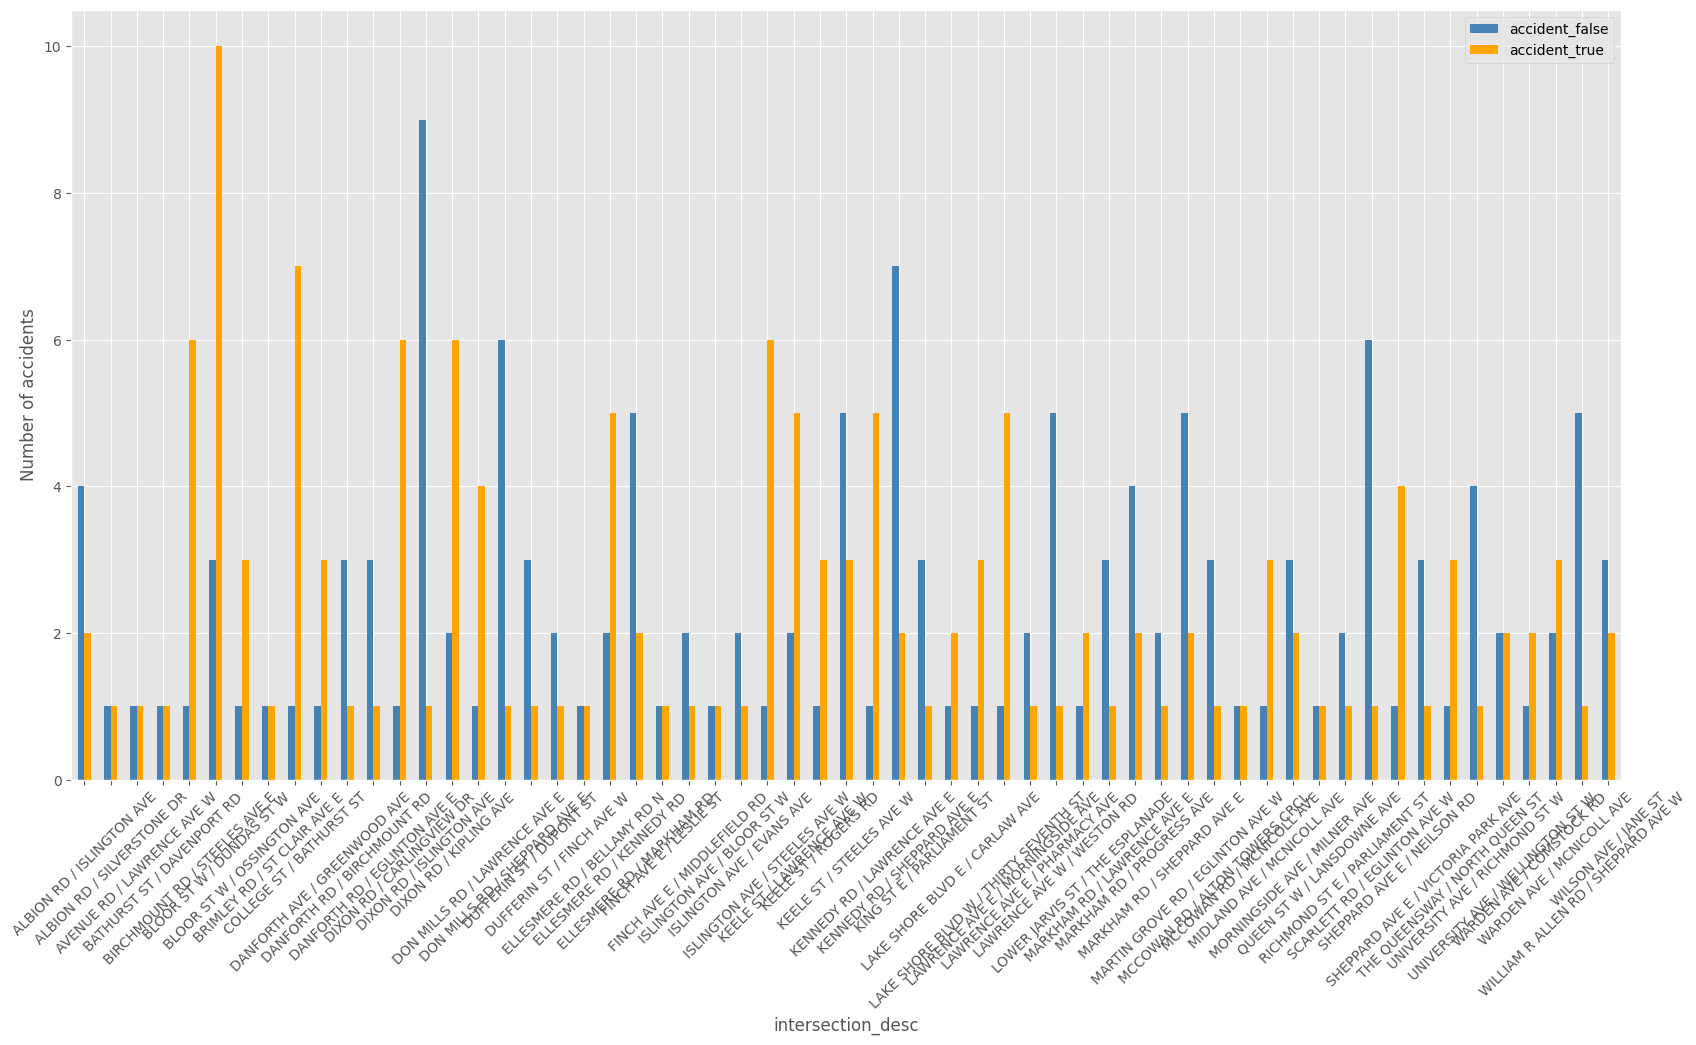

In [ ]:
ax = merged_acc_int_df.plot(kind="bar", x="intersection_desc", y=["accident_false", "accident_true"], rot=45, color=['steelblue','orange'], figsize=(20, 10));
ax.set_ylabel("Number of accidents");

From the above graphic that shows number of accidents per intersection before activating the RLC (in blue) vs after activating the RLC (in red)

We see that results are different from an intersection to another. Some registered a decrease in the number of accidents while others had an increase.

In [ ]:
#calculating the variation in the number of accidents and victims
merged_acc_int_df['accident_variation']=merged_acc_int_df['accident_true']-merged_acc_int_df['accident_false']
merged_acc_int_df['victims_variation']=merged_acc_int_df['victims_true']-merged_acc_int_df['victims_false']
merged_acc_int_df

,intersection_desc,index_x,victims_false,accident_false,index_y,victims_true,accident_true,accident_variation,victims_variation
0,ALBION RD / ISLINGTON AVE,7186,9,4,6444,11,2,-2,2
1,ALBION RD / SILVERSTONE DR,179,2,1,2901,1,1,0,-1
2,AVENUE RD / LAWRENCE AVE W,1420,5,1,3655,2,1,0,-3
3,BATHURST ST / DAVENPORT RD,155,1,1,3639,5,1,0,4
4,BIRCHMOUNT RD / STEELES AVE E,707,3,1,10645,20,6,5,17
5,BLOOR ST W / DUNDAS ST W,1157,6,3,16418,31,10,7,25
6,BLOOR ST W / OSSINGTON AVE,330,3,1,9561,7,3,2,4
7,BRIMLEY RD / ST CLAIR AVE E,623,3,1,1224,2,1,0,-1
8,COLLEGE ST / BATHURST ST,415,5,1,14247,17,7,6,12
9,DANFORTH AVE / GREENWOOD AVE,1007,4,1,5955,8,3,2,4


we have data before ad after RLC for 59 intersections only

In [ ]:
merged_acc_int_decrease_df=merged_acc_int_df[merged_acc_int_df.accident_variation<=0] #filtering the df to remove the positive values that represent increase in accidents
merged_acc_int_decrease_df

,intersection_desc,index_x,victims_false,accident_false,index_y,victims_true,accident_true,accident_variation,victims_variation
0,ALBION RD / ISLINGTON AVE,7186,9,4,6444,11,2,-2,2
1,ALBION RD / SILVERSTONE DR,179,2,1,2901,1,1,0,-1
2,AVENUE RD / LAWRENCE AVE W,1420,5,1,3655,2,1,0,-3
3,BATHURST ST / DAVENPORT RD,155,1,1,3639,5,1,0,4
7,BRIMLEY RD / ST CLAIR AVE E,623,3,1,1224,2,1,0,-1
10,DANFORTH RD / BIRCHMOUNT RD,2338,7,3,1317,5,1,-2,-2
11,DANFORTH RD / EGLINTON AVE E,3736,8,3,3108,10,1,-2,2
13,DIXON RD / ISLINGTON AVE,10798,29,9,3651,2,1,-8,-27
16,DON MILLS RD / SHEPPARD AVE E,15558,18,6,3729,2,1,-5,-16
17,DUFFERIN ST / DUPONT ST,6848,9,3,2355,15,1,-2,6


In [ ]:
merged_acc_int_decrease_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 37 entries, 0 to 58
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   intersection_desc   37 non-null     object
 1   index_x             37 non-null     int64 
 2   victims_false       37 non-null     int64 
 3   accident_false      37 non-null     int64 
 4   index_y             37 non-null     int64 
 5   victims_true        37 non-null     int64 
 6   accident_true       37 non-null     int64 
 7   accident_variation  37 non-null     int64 
 8   victims_variation   37 non-null     int64 
dtypes: int64(8), object(1)
memory usage: 2.9+ KB


Among the 59 intersection that had RLC installed. there are 37 that had equal or less accidents after the activation of the RLC
which represents 63%

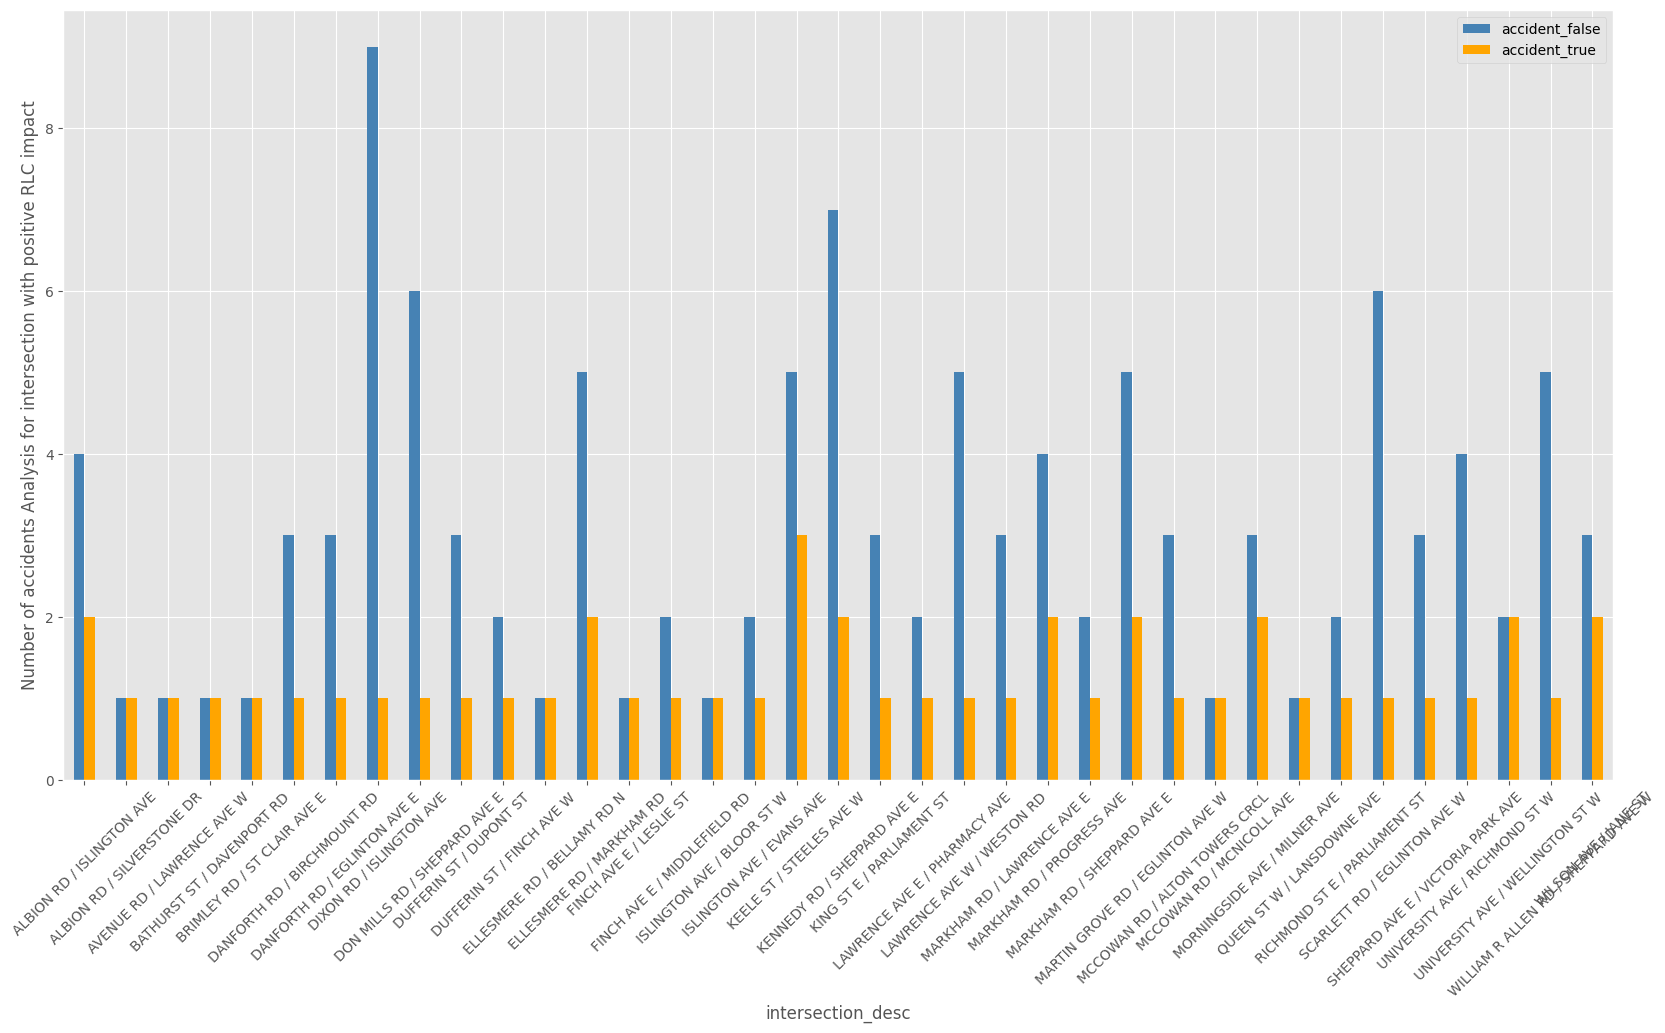

In [ ]:
ax = merged_acc_int_decrease_df.plot(kind="bar", x="intersection_desc", y=["accident_false", "accident_true"], rot=45,color=['steelblue','orange'], figsize=(20, 10));
ax.set_ylabel("Number of accidents Analysis for intersection with positive RLC impact");

# Analysis Goal # 7

**Run Machine learning algorithm on the filtered Dataframe, analyze the accuracy score to see how accurate is our algorithm**


* Create dataframe and prepare the data for classification.
* Using the pandas operators prepare the feature variables X and the response Y for the fit. Note that sklean expects data as arrays, so convert extracted columns into arrays.
* Split the data into train and test using sklearn train_test_split function.
* Run the fit using KNeighborsClassifier from sklearn.neighbors
* Instantiate the model
* Run the classifier on the training set
* Use learning model to predict the accident location from features, run prediction on X from test part.
* Show the accuracy score of the prediction











In [ ]:
#Import libraries
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore")


In [ ]:
#Create a dataframe and prepare the data for classification. Using the pandas operators prepare the feature variables X and the response Y for the fit. 
#Note that sklean expects data as arrays, so convert extracted columns into arrays.
#Create a copy of the DataFrame for this goal
pred_acc_df = mvc_ci_rlc_tvi_accidents_df.copy()
#Drop columns not needed for prediction
pred_acc_df.drop(['geometry', 'timestamp', 'INTERSECTION_DESC', 'CLASSIFICATION_DESC', 'NUMBER_OF_ELEVATIONS'], axis=1, inplace=True)
#Convert object and boolean values to numerical values - features_to_encode = 'RLC_Activated','VISIBILITY', 'LIGHT', 'RDSFCOND', 'TRAFFCTL'
pd.get_dummies(pred_acc_df.RLC_Activated)
RLC_Activated_dummies = pd.get_dummies(pred_acc_df.RLC_Activated)
pred_acc_df = pd.concat([pred_acc_df, RLC_Activated_dummies], axis=1)
pred_acc_df.drop('RLC_Activated', axis=1,inplace=True)


In [ ]:
pd.get_dummies(pred_acc_df.VISIBILITY)
VISIBILITY_dummies = pd.get_dummies(pred_acc_df.VISIBILITY)
pred_acc_df = pd.concat([pred_acc_df, VISIBILITY_dummies], axis=1)
pred_acc_df.drop('VISIBILITY', axis=1,inplace=True)

pd.get_dummies(pred_acc_df.LIGHT)
LIGHT_dummies = pd.get_dummies(pred_acc_df.LIGHT)
pred_acc_df = pd.concat([pred_acc_df, LIGHT_dummies], axis=1)
pred_acc_df.drop('LIGHT', axis=1,inplace=True)

pd.get_dummies(pred_acc_df.RDSFCOND)
RDSFCOND_dummies = pd.get_dummies(pred_acc_df.RDSFCOND)
pred_acc_df = pd.concat([pred_acc_df, RDSFCOND_dummies], axis=1)
pred_acc_df.drop('RDSFCOND', axis=1,inplace=True)

pd.get_dummies(pred_acc_df.TRAFFCTL)
TRAFFCTL_dummies = pd.get_dummies(pred_acc_df.TRAFFCTL)
pred_acc_df = pd.concat([pred_acc_df, TRAFFCTL_dummies], axis=1)
pred_acc_df.drop('TRAFFCTL', axis=1,inplace=True)



In [ ]:
#Change names that are lists
pred_acc_df.rename(columns={'Fog, Mist, Smoke, Dust':'Fog Mist Smoke Dust'},inplace=True)
pred_acc_df.rename(columns={'Dark, artificial':'Dark artificial'},inplace=True)
pred_acc_df.rename(columns={'Dawn, artificial':'Dawn artificial'},inplace=True)
pred_acc_df.rename(columns={'Daylight, artificial':'Daylight artificial'},inplace=True)
pred_acc_df.rename(columns={'Dusk, artificial':'Dusk artificial'},inplace=True)
pred_acc_df.rename(columns={'Streetcar (Stop for)':'Streetcar_Stop for'},inplace=True)
pred_acc_df.rename(columns={True:'RLC'},inplace=True)
pred_acc_df.rename(columns={False:'No_RLC'},inplace=True)
pred_acc_df = pred_acc_df.dropna()


In [ ]:
print(pred_acc_df.columns.to_list())

['ACCNUM', 'YEAR', 'DATE', 'TIME', 'STREET1', 'STREET2', 'OFFSET', 'ROAD_CLASS', 'DISTRICT', 'WARDNUM', 'LOCCOORD', 'ACCLOC', 'ACCLASS', 'IMPACTYPE', 'PEDESTRIAN', 'CYCLIST', 'AUTOMOBILE', 'MOTORCYCLE', 'TRUCK', 'TRSN_CITY_VEH', 'EMERG_VEH', 'PASSENGER', 'SPEEDING', 'AG_DRIV', 'REDLIGHT', 'ALCOHOL', 'DISABILITY', 'HOOD_158', 'NEIGHBOURHOOD_158', 'HOOD_140', 'NEIGHBOURHOOD_140', 'DIVISION', 'long', 'lat', 'ACTIVATION_DATE', 'hourly_cars', 'hourly_trucks', 'hourly_buses', 'hourly_pedestrians', 'hourly_bicycles', 'Victims', 'No_RLC', 'RLC', 'Clear', 'Drifting Snow', 'Fog Mist Smoke Dust', 'Freezing Rain', 'None', 'Other', 'Rain', 'Snow', 'Strong wind', 'Dark', 'Dark artificial', 'Dawn', 'Dawn artificial', 'Daylight', 'Daylight artificial', 'Dusk', 'Dusk artificial', 'Other', 'Dry', 'Ice', 'Loose Sand or Gravel', 'Loose Snow', 'None', 'Other', 'Packed Snow', 'Slush', 'Spilled liquid', 'Wet', 'No Control', 'None', 'Pedestrian Crossover', 'Police Control', 'School Guard', 'Stop Sign', 'Stree

In [ ]:
X = pred_acc_df[['ACCNUM', 'YEAR', 'long', 'WARDNUM', 'hourly_cars', 'hourly_trucks', 'hourly_buses', 'hourly_pedestrians', 'hourly_bicycles', 'Victims', 'No_RLC', "RLC", 'Clear', 'Drifting Snow', 'Fog Mist Smoke Dust', 'Freezing Rain', 'None', 'Other', 'Rain', 'Snow', 'Strong wind', 'Dark', 'Dark artificial', 'Dawn', 'Dawn artificial', 'Daylight', 'Daylight artificial', 'Dusk', 'Dusk artificial', 'Other', 'Dry', 'Ice', 'Loose Sand or Gravel', 'Loose Snow', 'None', 'Other', 'Packed Snow', 'Slush', 'Spilled liquid', 'Wet', 'No Control', 'None', 'Pedestrian Crossover', 'Police Control', 'School Guard', 'Stop Sign', 'Streetcar_Stop for', 'Traffic Controller', 'Traffic Gate', 'Traffic Signal', 'Yield Sign']]
y = pred_acc_df['lat']

print(X.shape)
print(y.shape)

(659, 63)
(659,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(527, 63)
(132, 63)
(527,)
(132,)


In [ ]:
#Run the fit using KNeighborsClassifier from sklearn.neighbors.
#First, instantiate the model,

from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler() 
scaler.fit(X_train) 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.min(), X_train_scaled.max())
print(X_test_scaled.min(), X_test_scaled.max())

0.0 1.0000000000000002
0.0 1.076923076923077


In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn.predict(X_test_scaled) 
print(y_pred.shape)
y_pred

(132,)


array([' 43.7370972916531', ' 43.6123076087867', ' 43.6482255186129',
       ' 43.6364779554631', ' 43.6667255135304', ' 43.7764362536762',
       ' 43.6839620912168', ' 43.6667255135304', ' 43.6687570794938',
       ' 43.7120456468031', ' 43.6798247350034', ' 43.6563210256757',
       ' 43.6942496435162', ' 43.6564819597087', ' 43.7590312927615',
       ' 43.7787310975215', ' 43.6942496435162', ' 43.7658020203849',
       ' 43.7643434795002', ' 43.7752446208589', ' 43.7120456468031',
       ' 43.7752446208589', ' 43.7853443362569', ' 43.6473629698271',
       ' 43.8111841512224', ' 43.6364779554631', ' 43.65455910154381',
       ' 43.6142177427093', ' 43.6942496435162', ' 43.7679249528153',
       ' 43.7222555964706', ' 43.6563210256757', ' 43.7494979730779',
       ' 43.677178739686', ' 43.7069989476323', ' 43.6263363553122',
       ' 43.7373545066246', ' 43.6970494522127', ' 43.7019482697628',
       ' 43.6798247350034', ' 43.7590312927615', ' 43.677178739686',
       ' 43.761852039

In [ ]:
from sklearn.metrics import accuracy_score
#Show the accuracy score of the prediction by comparing predicted accident classes and the Y values from the test.
accuracy_score(y_test, y_pred)

0.07575757575757576

In [ ]:
#Identify the number of correct predictions and predictions that were wrong. 
compare = (np.array(y_pred)==np.array(y_test))
compare

array([False, False, False,  True, False, False, False, False, False,
        True, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False,  True,
       False,  True,

In [ ]:
#Use NumPy's operator count_nonzero to count number of non-False values.
count = np.count_nonzero(compare)
count

10

In [ ]:
pred_acc_df.info()



<class 'pandas.core.frame.DataFrame'>
Int64Index: 659 entries, 84 to 3985
Data columns (total 82 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ACCNUM                659 non-null    int64         
 1   YEAR                  659 non-null    int64         
 2   DATE                  659 non-null    object        
 3   TIME                  659 non-null    int64         
 4   STREET1               659 non-null    object        
 5   STREET2               659 non-null    object        
 6   OFFSET                659 non-null    object        
 7   ROAD_CLASS            659 non-null    object        
 8   DISTRICT              659 non-null    object        
 9   WARDNUM               659 non-null    float64       
 10  LOCCOORD              659 non-null    object        
 11  ACCLOC                659 non-null    object        
 12  ACCLASS               659 non-null    object        
 13  IMPACTYPE         